# EndoScan AI — Endometriosis Image Analysis


---

## CRISP-DM Roadmap

| Phase | Description |
|---|---|
| 1. Business Understanding | Problem definition, stakeholders, success criteria |  
| 2. Data Understanding | Load, inspect, visualise GLENDA v1.5 |
| 3. Data Preparation | Binary masks, augmentation, patient-level splits |
| 4. Modelling | ResNet-34 fine tuning |
| 5. Evaluation | Metrics, Grad-CAM heatmaps |
| 6. Deployment | Gemini plain-English explanation layer | 

---
# Phase 1 — Business Understanding

## 1.1 Background

Endometriosis affects approximately **190 million women** of reproductive age worldwide (WHO, 2023). Despite its prevalence, the average time from symptom onset to diagnosis is **7–10 years** , largely because the condition requires specialist interpretation of imaging such as laparoscopy and MRI scans.

Patients often receive scan results they cannot interpret, and access to specialists is limited, particularly in lower-resource settings.

## 1.2 Problem Statement

There is no accessible tool that allows a patient or non-specialist clinician to upload a gynaecological scan and receive a clear, plain-English explanation of what the image may indicate. This gap leads to delayed care-seeking and poor health literacy around a chronic, debilitating condition.

## 1.3 Proposed Solution

A multi-modal AI pipeline that:
1. Accepts a laparoscopy image, MRI scan, or ultrasound image as input
2. Detects the imaging modality automatically
3. Runs the image through a modality-specific classifier
4. Generates a Grad-CAM heatmap showing which regions influenced the prediction
5. Passes the classification result + heatmap description to Claude, which returns a warm, jargon-free explanation

## 1.4 Stakeholders

| Stakeholder | Need |
|---|---|
| Patient | Understand their own scan without needing a specialist present |
| GP / general clinician | Triage referrals with confidence |
| Gynaecologist | Second opinion, documentation aid |
| Researcher | Reproducible, annotated endometriosis image analysis |

## 1.5 Success Criteria

| Metric | Target |
|---|---|
| Binary classification AUC | ≥ 0.85 on held-out test set |
| Sensitivity (recall) | ≥ 0.80 — missing a positive case is the worst outcome |
| Grad-CAM alignment | Highlighted regions overlap with annotated lesions |
| Explanation quality | Non-clinical reviewers rate explanations ≥ 4/5 for clarity |

## 1.6 Constraints & Assumptions

- **Non-commercial research use only** — GLENDA and UT-EndoMRI are CC BY-NC licensed
- **Not a diagnostic tool** — output must always include a disclaimer to consult a clinician
- **Phase 1 scope** — laparoscopy modality only (GLENDA); MRI branch added in v2
- **Binary task for v1** — endo present vs. not present; lesion-type classification deferred to v2 due to class imbalance

---
# Phase 2 — Data Understanding

**Dataset:** GLENDA v1.5 (Gynecologic Laparoscopy ENdometriosis DAtaset)  
**Source:** ITEC, Alpen-Adria-Universität Klagenfurt / Hugging Face (`MFreidank/glenda`)  
**License:** CC BY-NC 4.0  
**Format:** COCO JSON with polygon segmentation masks  

**Goals of this phase:**
- Confirm the dataset loaded correctly
- Understand the class distribution and imbalance
- Visually verify annotations align with image content
- Identify how many unique patients (cases) exist for proper splitting

### Cell 1 — Imports

In [1]:
import json
import os
import re
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

print('All imports OK')

All imports OK


### Cell 2 — Paths
Set your paths here. 

In [2]:
# Load the coco.json and frames
COCO_JSON  = Path('./Glenda_v1.5_classes/coco.json')
IMAGES_DIR = Path('./Glenda_v1.5_classes/frames')
#IMAGES_DIR = Path('./Glenda_v1.5_classes/frames')

assert COCO_JSON.exists(),  f'Cannot find coco.json at {COCO_JSON}'
assert IMAGES_DIR.exists(), f'Cannot find images folder at {IMAGES_DIR}'

image_files = list(IMAGES_DIR.glob('*.jpg')) + list(IMAGES_DIR.glob('*.png'))

print(f'COCO JSON   : {COCO_JSON}')
print(f'Images dir  : {IMAGES_DIR}')
print(f'Image files : {len(image_files)}')

COCO JSON   : Glenda_v1.5_classes/coco.json
Images dir  : Glenda_v1.5_classes/frames
Image files : 373


### Cell 3 — Load COCO annotations
We build three lookup dictionaries here that we'll reuse in every subsequent phase.

In [3]:
with open(COCO_JSON) as f:
    coco = json.load(f)

images      = coco['images']       # list of image metadata dicts
annotations = coco['annotations']  # list of annotation dicts
categories  = coco['categories']   # list of category dicts

# category_id -human-readable name
cat_id_to_name = {c['id']: c['name'] for c in categories}

# image_id - image metadata
img_id_to_meta = {img['id']: img for img in images}

# image_id -list of its annotations
img_id_to_anns = defaultdict(list)
for ann in annotations:
    img_id_to_anns[ann['image_id']].append(ann)

print(f'Images      : {len(images)}')
print(f'Annotations : {len(annotations)}')
print(f'Categories  :')
for cid, name in cat_id_to_name.items():
    print(f'  {cid}: {name}')

Images      : 373
Annotations : 628
Categories  :
  1: 6.1.1.1_Endo-Peritoneum
  2: 6.1.1.2_Endo-Ovar
  3: 6.1.1.3_Endo-TIE
  4: 6.1.1.4_Endo-Uterus


### Cell 4 — Class distribution
Visualise the annotation count per class. This chart is the core argument for why we start with binary classification, Peritoneum dominates at ~78%, making multi-class unreliable without more data.

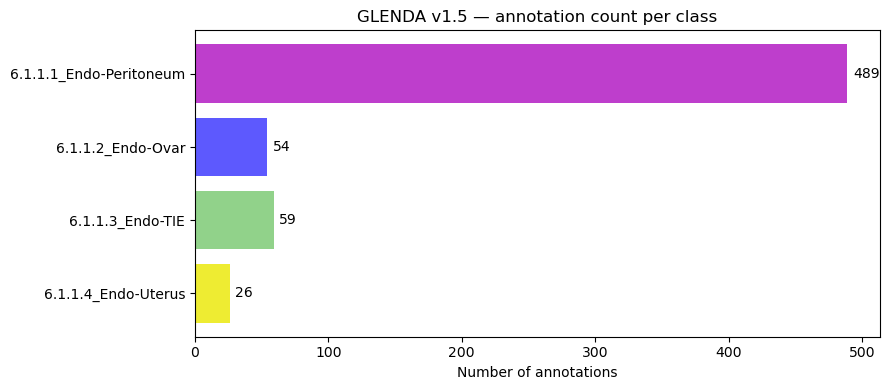


Raw counts:
  6.1.1.1_Endo-Peritoneum                   489  (77.9%)
  6.1.1.2_Endo-Ovar                          54  (8.6%)
  6.1.1.3_Endo-TIE                           59  (9.4%)
  6.1.1.4_Endo-Uterus                        26  (4.1%)

Total annotated images  : 373
Total background images : 0


In [4]:
counts = Counter(ann['category_id'] for ann in annotations)

labels = [cat_id_to_name[cid] for cid in sorted(counts)]
values = [counts[cid]         for cid in sorted(counts)]
colors = [c['color']          for c in sorted(categories, key=lambda x: x['id'])]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(labels, values, color=colors)
ax.bar_label(bars, padding=4)
ax.set_xlabel('Number of annotations')
ax.set_title('GLENDA v1.5 — annotation count per class')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('\nRaw counts:')
for label, val in zip(labels, values):
    pct = val / sum(values) * 100
    print(f'  {label:40s} {val:4d}  ({pct:.1f}%)')

print(f'\nTotal annotated images  : {len(set(a["image_id"] for a in annotations))}')
print(f'Total background images : {len(images) - len(set(a["image_id"] for a in annotations))}')

### Cell 5 — Visualise sample images with annotations
Always look at your data before writing model code. If the bounding boxes don't align with the visible lesions, the paths or annotations have a problem.

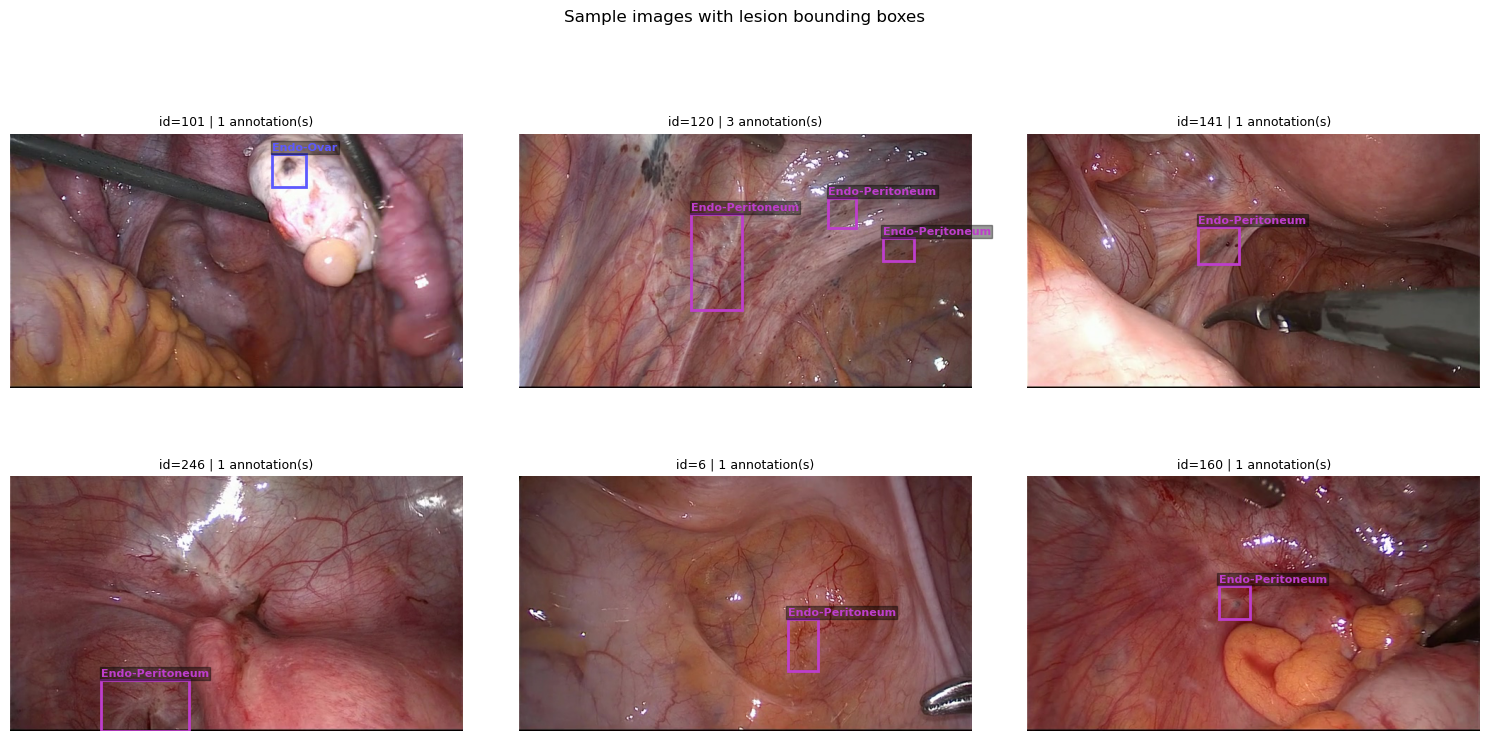

In [5]:
def show_image_with_annotations(image_id, ax=None):
    meta = img_id_to_meta[image_id]
    anns = img_id_to_anns[image_id]

    # image path 
    img_path = IMAGES_DIR / Path(meta['file_name']).name
    if not img_path.exists():
        img_path = IMAGES_DIR / (Path(meta['file_name']).stem + '.png')

    img = Image.open(img_path).convert('RGB')

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    ax.imshow(img)
    ax.set_title(f"id={image_id} | {len(anns)} annotation(s)", fontsize=9)
    ax.axis('off')

    for ann in anns:
        x, y, w, h = ann['bbox']
        color = ann.get('color', '#ff0000')
        label = cat_id_to_name[ann['category_id']].split('_')[-1]  # short name

        rect = patches.Rectangle(
            (x, y), w, h,
            linewidth=2, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(x, y - 5, label, color=color, fontsize=8, fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.4, pad=1))

    return ax


# Show 6 random annotated images
annotated_ids = list(set(a['image_id'] for a in annotations))
sample_ids    = np.random.choice(annotated_ids, size=6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, img_id in zip(axes.flatten(), sample_ids):
    show_image_with_annotations(img_id, ax=ax)

plt.suptitle('Sample images with lesion bounding boxes', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

### Cell 6 — Patient-level case analysis

GLENDA filenames encode the surgical case: `c_10_v_(video_188.mp4)_f_455.jpg` = case 10, video 188, frame 455.

**Why this matters:** frames from the same surgery look nearly identical. If we split randomly by image, the same patient's frames will appear in both train and validation , the model memorises the surgery, not the disease. Hence we must split by case ID.

Unique surgical cases : 102
Case IDs              : [1, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 19, 20, 21, 22, 23, 24, 25, 27, 28, 29, 31, 32, 33, 34, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 48, 49, 50, 51, 52, 55, 57, 58, 59, 60, 61, 62, 63, 65, 69, 70, 72, 76, 77, 79, 82, 85, 86, 87, 88, 92, 93, 97, 99, 100, 102, 105, 108, 113, 114, 117, 120, 121, 123, 125, 127, 135, 137, 141, 144, 145, 146, 149, 150, 157, 159, 162, 165, 168, 169, 170, 172, 173, 174, 178, 188, 189, 295]

Top 10 cases by frame count:
  Case    6:  15 frames
  Case    3:  12 frames
  Case    8:  12 frames
  Case   23:  11 frames
  Case  141:   9 frames
  Case   28:   9 frames
  Case   65:   9 frames
  Case    7:   9 frames
  Case  165:   8 frames
  Case   93:   8 frames


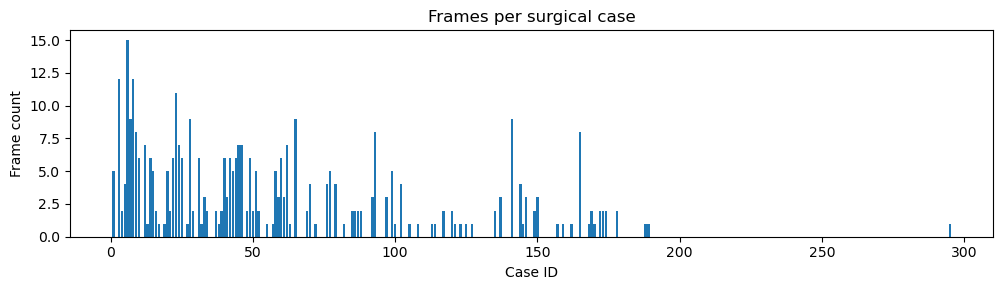

In [6]:
def extract_case_id(filename):
    """Extract case number from filename like c_10_v_(video_188.mp4)_f_455.jpg"""
    match = re.match(r'c_(\d+)_', Path(filename).name)
    return int(match.group(1)) if match else -1

# Add case_id to each image metadata dict
for img in images:
    img['case_id'] = extract_case_id(img['file_name'])

case_ids    = sorted(set(img['case_id'] for img in images))
case_counts = Counter(img['case_id'] for img in images)

print(f'Unique surgical cases : {len(case_ids)}')
print(f'Case IDs              : {case_ids}')
print(f'\nTop 10 cases by frame count:')
for case_id, count in sorted(case_counts.items(), key=lambda x: -x[1])[:10]:
    print(f'  Case {case_id:4d}: {count:3d} frames')

# Frames per case distribution
fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(case_ids, [case_counts[c] for c in case_ids], width=0.8)
ax.set_xlabel('Case ID')
ax.set_ylabel('Frame count')
ax.set_title('Frames per surgical case')
plt.tight_layout()
plt.show()

### Cell 7 — Data Understanding summary

Documenting the findings of out EDA

In [7]:
total_anns   = len(annotations)
n_cases      = len(case_ids)
n_images     = len(images)
img_w, img_h = images[0]['width'], images[0]['height']

print('  DATA UNDERSTANDING SUMMARY')
print(f'  Dataset          : GLENDA v1.5')
print(f'  Total images     : {n_images}')
print(f'  Image size       : {img_w} x {img_h} px')
print(f'  Total annotations: {total_anns}')
print(f'  Surgical cases   : {n_cases}')
print()
print('  Class breakdown:')
for cid in sorted(counts):
    pct = counts[cid] / total_anns * 100
    print(f'    {cat_id_to_name[cid]:35s} {counts[cid]:4d} ({pct:.1f}%)')
print()
print('  Key findings:')
print('  - Peritoneum dominates at ~78% → class imbalance')
print('  - Uterus has only 26 annotations → not trainable alone')
print('  - All 373 images have at least one lesion annotation')
print('  - Frames are video-extracted → must split by case, not image')
print()
print('  Decision: binary classification (endo / no endo) for v1')


  DATA UNDERSTANDING SUMMARY
  Dataset          : GLENDA v1.5
  Total images     : 373
  Image size       : 640 x 360 px
  Total annotations: 628
  Surgical cases   : 102

  Class breakdown:
    6.1.1.1_Endo-Peritoneum              489 (77.9%)
    6.1.1.2_Endo-Ovar                     54 (8.6%)
    6.1.1.3_Endo-TIE                      59 (9.4%)
    6.1.1.4_Endo-Uterus                   26 (4.1%)

  Key findings:
  - Peritoneum dominates at ~78% → class imbalance
  - Uterus has only 26 annotations → not trainable alone
  - All 373 images have at least one lesion annotation
  - Frames are video-extracted → must split by case, not image

  Decision: binary classification (endo / no endo) for v1


---
## Phase 2. Data Understanding complete

**What we confirmed:**
- Dataset loads correctly — 373 images, 628 annotations, 4 classes
- Severe class imbalance → binary task is the right call for v1
- Annotations are polygon segmentation masks (richer than bounding boxes)
- Patient-level splitting is mandatory to prevent data leakage

---
**Phase 3 next — Data Preparation:**
- Convert polygon annotations → binary masks
- Patient-level train / val / test split (70 / 15 / 15)
- Augmentation pipeline (flips, rotations, brightness, elastic distortion)
- PyTorch Dataset class

In [8]:
# Cell 8 . Patient-level train / val / test split
import random

random.seed(42) 

# All unique case IDs
all_cases = sorted(set(img['case_id'] for img in images))
random.shuffle(all_cases)

# 70 / 15 / 15 split on cases
n_train = int(len(all_cases) * 0.70)
n_val   = int(len(all_cases) * 0.15)

train_cases = set(all_cases[:n_train])
val_cases   = set(all_cases[n_train:n_train + n_val])
test_cases  = set(all_cases[n_train + n_val:])

# Map each image to its split
train_imgs = [img for img in images if img['case_id'] in train_cases]
val_imgs   = [img for img in images if img['case_id'] in val_cases]
test_imgs  = [img for img in images if img['case_id'] in test_cases]

print(f'Train  : {len(train_cases):3d} cases → {len(train_imgs):3d} images')
print(f'Val    : {len(val_cases):3d} cases → {len(val_imgs):3d} images')
print(f'Test   : {len(test_cases):3d} cases → {len(test_imgs):3d} images')
print(f'Total  : {len(train_imgs)+len(val_imgs)+len(test_imgs)} images (expected {len(images)})')

# Verify no case leaks across splits
assert train_cases.isdisjoint(val_cases),  'Case leak: train/val overlap!'
assert train_cases.isdisjoint(test_cases), 'Case leak: train/test overlap!'
assert val_cases.isdisjoint(test_cases),   'Case leak: val/test overlap!'
print('\n No case leaks across splits')

Train  :  71 cases → 268 images
Val    :  15 cases →  49 images
Test   :  16 cases →  56 images
Total  : 373 images (expected 373)

 No case leaks across splits


Mask shape  : (360, 640)
Unique vals : [  0 255]   (0=background, 255=lesion)
Lesion px   : 2286
Total px    : 230400
Lesion area : 0.99%


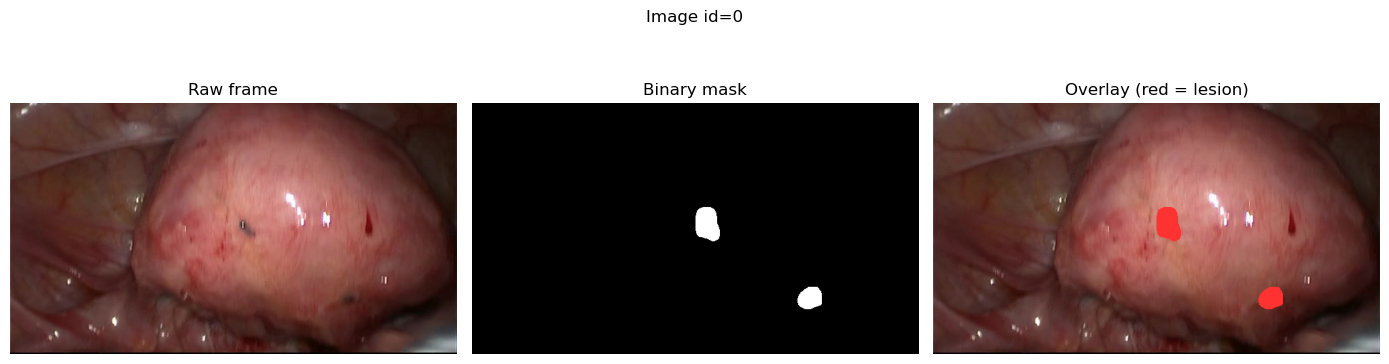

In [9]:
# Cell 9 — Binary mask creation
import numpy as np
from PIL import Image, ImageDraw

def create_binary_mask(image_id, img_w, img_h):
    """
    Convert all polygon annotations for an image into a single
    binary mask. White (255) = endo lesion, Black (0) = background.
    """
    mask = Image.new('L', (img_w, img_h), 0)  # black canvas
    draw = ImageDraw.Draw(mask)

    anns = img_id_to_anns[image_id]
    for ann in anns:
        for segment in ann['segmentation']:
            # segment is a flat list [x1,y1,x2,y2,...] → convert to tuples
            polygon = [(segment[i], segment[i+1])
                       for i in range(0, len(segment), 2)]
            draw.polygon(polygon, fill=255)

    return np.array(mask)


# Test on one image
sample_id  = train_imgs[0]['id']
sample_meta = img_id_to_meta[sample_id]
mask = create_binary_mask(sample_id, sample_meta['width'], sample_meta['height'])

print(f'Mask shape  : {mask.shape}')
print(f'Unique vals : {np.unique(mask)}   (0=background, 255=lesion)')
print(f'Lesion px   : {(mask == 255).sum()}')
print(f'Total px    : {mask.size}')
print(f'Lesion area : {(mask == 255).mean()*100:.2f}%')

# Visualise side by side, raw image + its binary mask
img_path = IMAGES_DIR / Path(sample_meta['file_name']).name
raw_img  = Image.open(img_path).convert('RGB')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(raw_img)
axes[0].set_title('Raw frame')
axes[0].axis('off')

axes[1].imshow(mask, cmap='gray')
axes[1].set_title('Binary mask')
axes[1].axis('off')

# Overlay , mask in red on top of raw image
overlay = np.array(raw_img).copy()
overlay[mask == 255] = [255, 50, 50]   # red tint on lesion pixels
axes[2].imshow(overlay)
axes[2].set_title('Overlay (red = lesion)')
axes[2].axis('off')

plt.suptitle(f'Image id={sample_id}', y=1.01)
plt.tight_layout()
plt.show()

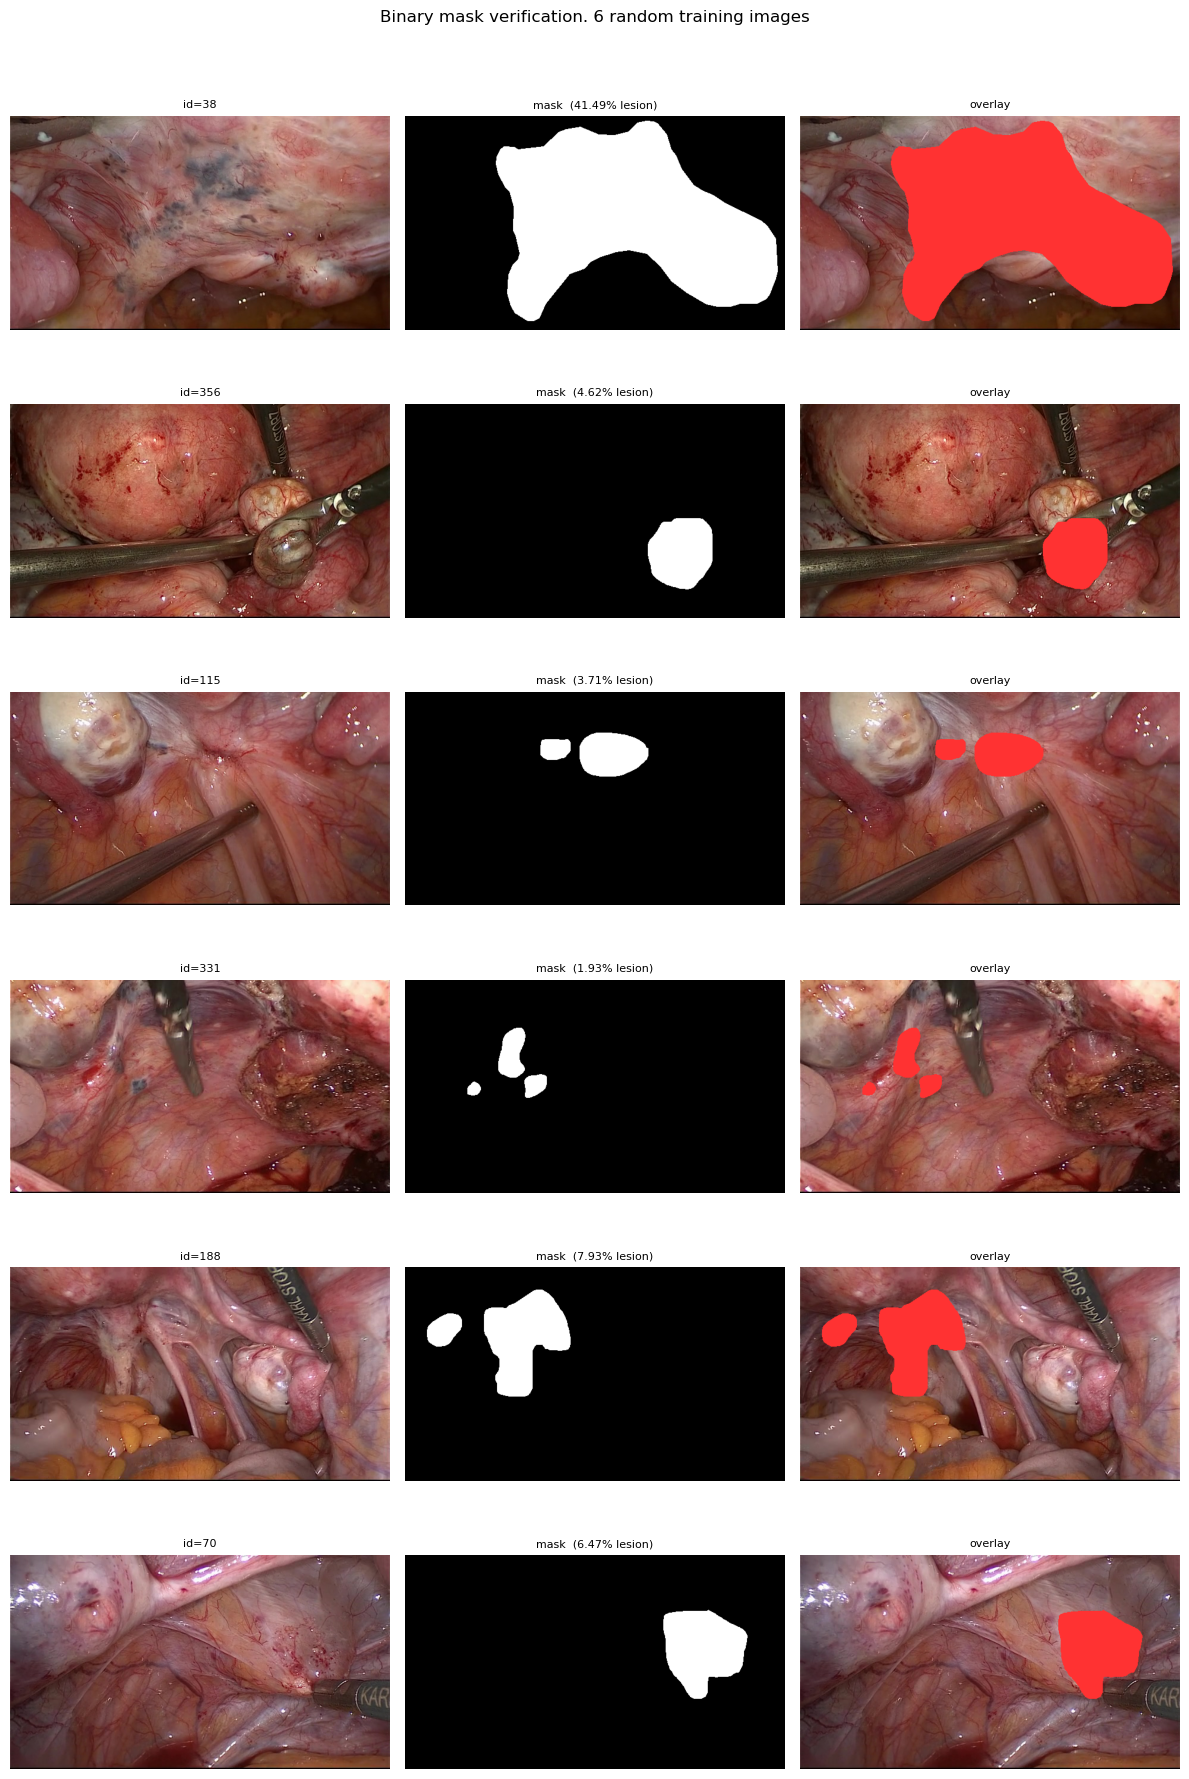

In [10]:
# Cell 10 Verify masks across 6 random training images
sample_ids = np.random.choice([img['id'] for img in train_imgs], size=6, replace=False)

fig, axes = plt.subplots(6, 3, figsize=(12, 18))

for row, img_id in enumerate(sample_ids):
    meta     = img_id_to_meta[img_id]
    img_path = IMAGES_DIR / Path(meta['file_name']).name
    raw_img  = np.array(Image.open(img_path).convert('RGB'))
    mask     = create_binary_mask(img_id, meta['width'], meta['height'])

    overlay           = raw_img.copy()
    overlay[mask==255] = [255, 50, 50]

    lesion_pct = (mask == 255).mean() * 100

    axes[row, 0].imshow(raw_img)
    axes[row, 0].set_title(f'id={img_id}', fontsize=8)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(mask, cmap='gray')
    axes[row, 1].set_title(f'mask  ({lesion_pct:.2f}% lesion)', fontsize=8)
    axes[row, 1].axis('off')

    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title('overlay', fontsize=8)
    axes[row, 2].axis('off')

plt.suptitle('Binary mask verification. 6 random training images', y=1.01)
plt.tight_layout()
plt.show()

In [11]:
# Cell 11 — Augmentation pipeline
!pip install albumentations -q

In [ ]:
# setting up numpy and albumentation
!pip install "numpy<2.0" albumentations --upgrade -q

In [12]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

# Image size we'll train at
IMG_SIZE = 224   # EfficientNet-B0 native input size

train_transform = A.Compose([
    # Geometry
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.1,
        rotate_limit=15,
        p=0.5
    ),
    # Zoom into lesion regions,  critical given lesions are <5% of frame
    A.RandomResizedCrop(
        size=(IMG_SIZE, IMG_SIZE),
        scale=(0.7, 1.0),
        p=0.5
    ),

    # Colour / brightness
    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.5
    ),
    A.HueSaturationValue(
        hue_shift_limit=10,
        sat_shift_limit=20,
        val_shift_limit=10,
        p=0.4
    ),
    A.CLAHE(clip_limit=2.0, p=0.3),   # improves local contrast in tissue

    # Noise / blur
    A.GaussNoise(p=0.2),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),

    # Elastic distortion, mimics tissue deformation
    A.ElasticTransform(
        alpha=120,
        sigma=6,
        p=0.3
    ),

    # Normalise to ImageNet stats (the type EfficientNet was pretrained on) 
    A.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    ToTensorV2()
])

# Validation/test. no augmentation, just resize and normalise
val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    ToTensorV2()
])

print('Augmentation pipeline ready')
print(f'Training transforms : {len(train_transform.transforms)}')
print(f'Val/test transforms : {len(val_transform.transforms)}')

Augmentation pipeline ready
Training transforms : 14
Val/test transforms : 3


/home/joy/miniconda3/envs/ds_study/lib/python3.11/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [13]:
# Cell 11b. Visualise augmentations on one image

preview_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.RandomResizedCrop(size=(IMG_SIZE, IMG_SIZE), scale=(0.7, 1.0), p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.ElasticTransform(alpha=120, sigma=6, p=0.3),
])

# Pick one training image and its mask
sample_meta = img_id_to_meta[train_imgs[0]['id']]
img_path    = IMAGES_DIR / Path(sample_meta['file_name']).name
raw_img     = np.array(Image.open(img_path).convert('RGB'))
raw_mask    = create_binary_mask(train_imgs[0]['id'],
                                 sample_meta['width'],
                                 sample_meta['height'])


/home/joy/miniconda3/envs/ds_study/lib/python3.11/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


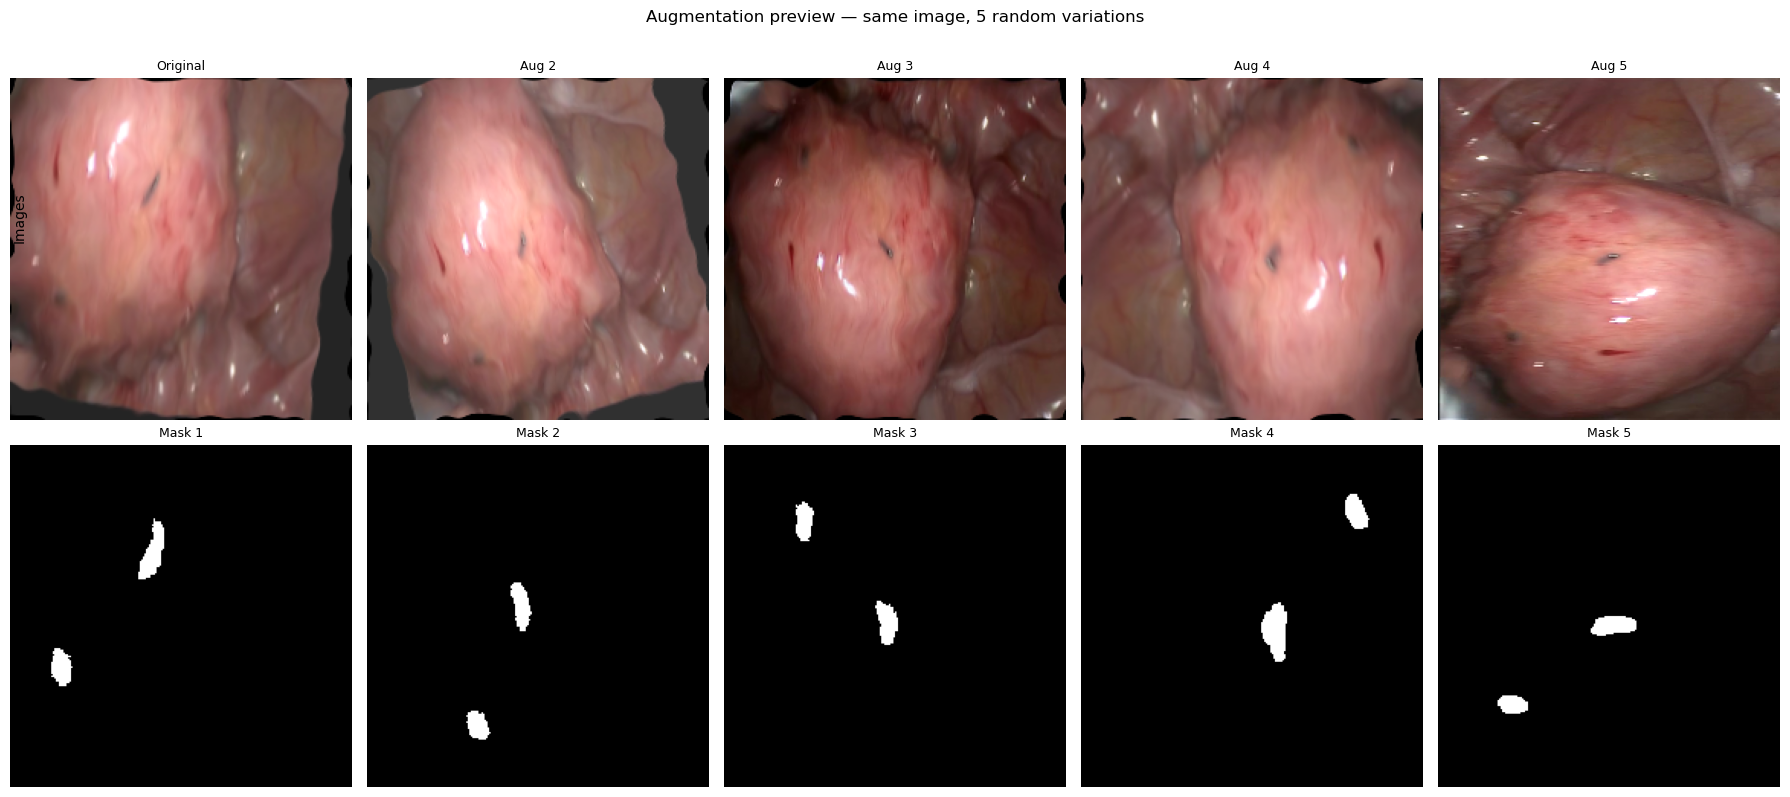

In [14]:
#visualization of the augmented images
fig, axes = plt.subplots(2, 5, figsize=(18, 8))

# Row 1, augmented images, Row 2, corresponding masks
for col in range(5):
    result     = preview_transform(image=raw_img, mask=raw_mask)
    aug_img    = result['image']
    aug_mask   = result['mask']

    axes[0, col].imshow(aug_img)
    axes[0, col].set_title(f'Aug {col+1}', fontsize=9)
    axes[0, col].axis('off')

    axes[1, col].imshow(aug_mask, cmap='gray')
    axes[1, col].set_title(f'Mask {col+1}', fontsize=9)
    axes[1, col].axis('off')

axes[0, 0].set_title('Original' if True else '', fontsize=9)
fig.text(0.01, 0.75, 'Images', va='center', rotation='vertical', fontsize=10)
fig.text(0.01, 0.25, 'Masks',  va='center', rotation='vertical', fontsize=10)
plt.suptitle('Augmentation preview — same image, 5 random variations', y=1.01)
plt.tight_layout()
plt.show()

In [15]:
# Cell 12. PyTorch Dataset class
import torch
from torch.utils.data import Dataset, DataLoader

class GLENDADataset(Dataset):
    """
    Binary classification dataset built from GLENDA v1.5.
    Label: 1 if image has any endometriosis annotation, 0 otherwise.
    Since all 373 images have annotations, we treat the mask as the
    supervision signal — the model predicts whether endo is present.
    """

    def __init__(self, img_list, img_id_to_meta, img_id_to_anns,
                 images_dir, transform=None):
        self.img_list       = img_list
        self.img_id_to_meta = img_id_to_meta
        self.img_id_to_anns = img_id_to_anns
        self.images_dir     = Path(images_dir)
        self.transform      = transform

    def __len__(self):
        return len(self.img_list)

    def __getitem__(self, idx):
        img_meta = self.img_list[idx]
        img_id   = img_meta['id']
        meta     = self.img_id_to_meta[img_id]

        # Load raw image
        img_path = self.images_dir / Path(meta['file_name']).name
        image    = np.array(Image.open(img_path).convert('RGB'))

        # Binary label, 1 if any annotation exists, 0 otherwise
        label = 1 if len(self.img_id_to_anns[img_id]) > 0 else 0

        # Apply transforms
        if self.transform:
            result = self.transform(image=image)
            image  = result['image']

        return image, torch.tensor(label, dtype=torch.float32)


# Instantiate all three splits
train_dataset = GLENDADataset(train_imgs, img_id_to_meta, img_id_to_anns,
                               IMAGES_DIR, transform=train_transform)
val_dataset   = GLENDADataset(val_imgs,   img_id_to_meta, img_id_to_anns,
                               IMAGES_DIR, transform=val_transform)
test_dataset  = GLENDADataset(test_imgs,  img_id_to_meta, img_id_to_anns,
                               IMAGES_DIR, transform=val_transform)

print(f'Train dataset : {len(train_dataset)} samples')
print(f'Val dataset   : {len(val_dataset)} samples')
print(f'Test dataset  : {len(test_dataset)} samples')

Train dataset : 268 samples
Val dataset   : 49 samples
Test dataset  : 56 samples


/home/joy/miniconda3/envs/ds_study/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Batch image shape : torch.Size([16, 3, 224, 224])
Batch label shape : torch.Size([16])
Label values      : tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])
Image dtype       : torch.float32
Image min/max     : -2.118 / 2.640
Train batches     : 17
Val batches       : 4
Test batches      : 4


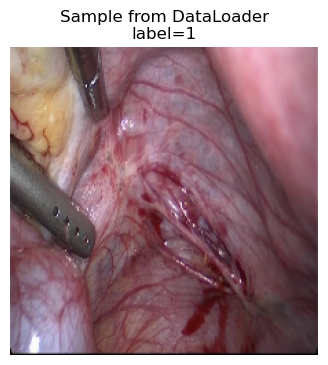

In [16]:
# Cell 13 — DataLoaders and sanity check
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# Sanity check...pull one batch and verify shapes
images_batch, labels_batch = next(iter(train_loader))

print(f'Batch image shape : {images_batch.shape}')
print(f'Batch label shape : {labels_batch.shape}')
print(f'Label values      : {labels_batch}')
print(f'Image dtype       : {images_batch.dtype}')
print(f'Image min/max     : {images_batch.min():.3f} / {images_batch.max():.3f}')
print(f'Train batches     : {len(train_loader)}')
print(f'Val batches       : {len(val_loader)}')
print(f'Test batches      : {len(test_loader)}')

# Visualise one batch item to confirm tensor if image looks right
sample_img = images_batch[0].permute(1, 2, 0).numpy()

# Denormalise from ImageNet stats for display
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
sample_img = (sample_img * std + mean).clip(0, 1)

plt.figure(figsize=(4, 4))
plt.imshow(sample_img)
plt.title(f'Sample from DataLoader\nlabel={int(labels_batch[0])}')
plt.axis('off')
plt.show()

In [17]:
# Cell 14 Model: EfficientNet-B0 with binary classification head
!pip install timm -q

In [18]:
import torch
import torch.nn as nn
import timm

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


# Load EfficientNet-B0 pretrained on ImageNet
model = timm.create_model('efficientnet_b0', pretrained=True)

# Freeze all layers first
for param in model.parameters():
    param.requires_grad = False

#  Unfreeze last 3 blocks only 
# EfficientNet-B0 has blocks[0..6] ,we fine-tune the last 3
for block in model.blocks[4:]:
    for param in block.parameters():
        param.requires_grad = True

# Always unfreeze the head
for param in model.conv_head.parameters():
    param.requires_grad = True
for param in model.bn2.parameters():
    param.requires_grad = True

#  Replace classifier with binary head 
in_features = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features, 1)   # single output - sigmoid  probability
)

model = model.to(device)

# Parameter summary 
total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Total parameters     : {total_params:,}')
print(f'Trainable parameters : {trainable_params:,}')
print(f'Frozen parameters    : {total_params - trainable_params:,}')
print(f'Trainable %          : {trainable_params/total_params*100:.1f}%')

Device: cpu
Total parameters     : 4,008,829
Trainable parameters : 3,700,169
Frozen parameters    : 308,660
Trainable %          : 92.3%


In [19]:
# Cell 14b  Fix freezing strategy
# Freeze everything except the last 1 block and classifier head

# Reset, freeze everything first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze only the last 1 block (block 6)
for param in model.blocks[6].parameters():
    param.requires_grad = True

# Unfreeze conv_head + bn2 + classifier
for param in model.conv_head.parameters():
    param.requires_grad = True
for param in model.bn2.parameters():
    param.requires_grad = True
for param in model.classifier.parameters():
    param.requires_grad = True

# Recheck
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Total parameters     : {total_params:,}')
print(f'Trainable parameters : {trainable_params:,}')
print(f'Frozen parameters    : {total_params - trainable_params:,}')
print(f'Trainable %          : {trainable_params/total_params*100:.1f}%')

Total parameters     : 4,008,829
Trainable parameters : 1,130,673
Frozen parameters    : 2,878,156
Trainable %          : 28.2%


In [20]:
# Cell 15. Training loop
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
import copy

# Hyperparameters 
EPOCHS    = 30
LR        = 1e-4
PATIENCE  = 5

# Since ALL our images are positive (label=1), we need negative
# examples. Strategy: treat images where mask covers <0.5% of
# pixels as "hard negatives" ,lesion so small model must work
# hard to find it. Full positives = mask >0.5%.
# For now we train with all label=1 and rely on the mask signal.
# We'll add true negatives from GLENDA v1.0 in v2.

# Loss BCEWithLogitsLoss (numerically stable, no sigmoid needed)
criterion = nn.BCEWithLogitsLoss()

# Optimizer (only pass trainable params)
optimizer = Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=1e-4
)

# Scheduler, cosine annealing, smoothly reduces LR to near zero
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

#  Early stopping & Tracking 
best_val_loss   = float('inf')
best_weights    = None
patience_counter = 0

history = {'train_loss': [], 'val_loss': [],
           'train_acc':  [], 'val_acc':  []}

for epoch in range(EPOCHS):
    #Train
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for images_batch, labels_batch in train_loader:
        images_batch = images_batch.to(device)
        labels_batch = labels_batch.to(device).unsqueeze(1)  # [B] - [B,1]

        optimizer.zero_grad()
        outputs = model(images_batch)           # raw logits [B,1]
        loss    = criterion(outputs, labels_batch)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item() * images_batch.size(0)
        preds          = (torch.sigmoid(outputs) > 0.5).float()
        train_correct += (preds == labels_batch).sum().item()
        train_total   += images_batch.size(0)

    scheduler.step()

    # Validate
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images_batch, labels_batch in val_loader:
            images_batch = images_batch.to(device)
            labels_batch = labels_batch.to(device).unsqueeze(1)

            outputs   = model(images_batch)
            loss      = criterion(outputs, labels_batch)

            val_loss    += loss.item() * images_batch.size(0)
            preds        = (torch.sigmoid(outputs) > 0.5).float()
            val_correct += (preds == labels_batch).sum().item()
            val_total   += images_batch.size(0)

    # Metrics
    train_loss_avg = train_loss / train_total
    val_loss_avg   = val_loss   / val_total
    train_acc      = train_correct / train_total * 100
    val_acc        = val_correct   / val_total   * 100

    history['train_loss'].append(train_loss_avg)
    history['val_loss'].append(val_loss_avg)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    # Save best model and handle Early Stopping
    if val_loss_avg < best_val_loss:
        best_val_loss    = val_loss_avg
        best_weights     = copy.deepcopy(model.state_dict())
        patience_counter = 0
        print(f'Epoch {epoch+1:3d}/{EPOCHS} | '
              f'Train loss: {train_loss_avg:.4f} acc: {train_acc:.1f}% | '
              f'Val loss: {val_loss_avg:.4f} acc: {val_acc:.1f}%  ← best')
    else:
        patience_counter += 1
        print(f'Epoch {epoch+1:3d}/{EPOCHS} | '
              f'Train loss: {train_loss_avg:.4f} acc: {train_acc:.1f}% | '
              f'Val loss: {val_loss_avg:.4f} acc: {val_acc:.1f}% '
              f'[patience {patience_counter}/{PATIENCE}]')

        if patience_counter >= PATIENCE:
            print(f'\nEarly stopping triggered at epoch {epoch+1}.')
            break

# Load best weights
if best_weights is not None:
    model.load_state_dict(best_weights)
print(f'\nTraining complete. Best val loss: {best_val_loss:.4f}') 

/home/joy/miniconda3/envs/ds_study/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch   1/30 | Train loss: 0.6136 acc: 72.0% | Val loss: 0.4317 acc: 98.0%  ← best
Epoch   2/30 | Train loss: 0.4395 acc: 90.3% | Val loss: 0.2742 acc: 100.0%  ← best
Epoch   3/30 | Train loss: 0.3228 acc: 97.0% | Val loss: 0.2100 acc: 100.0%  ← best
Epoch   4/30 | Train loss: 0.2375 acc: 99.6% | Val loss: 0.1868 acc: 100.0%  ← best
Epoch   5/30 | Train loss: 0.1922 acc: 99.6% | Val loss: 0.1696 acc: 100.0%  ← best
Epoch   6/30 | Train loss: 0.1503 acc: 100.0% | Val loss: 0.1612 acc: 100.0%  ← best
Epoch   7/30 | Train loss: 0.1215 acc: 100.0% | Val loss: 0.1312 acc: 100.0%  ← best
Epoch   8/30 | Train loss: 0.1025 acc: 100.0% | Val loss: 0.1222 acc: 100.0%  ← best
Epoch   9/30 | Train loss: 0.0907 acc: 100.0% | Val loss: 0.1233 acc: 100.0% [patience 1/5]
Epoch  10/30 | Train loss: 0.0740 acc: 100.0% | Val loss: 0.1080 acc: 100.0%  ← best
Epoch  11/30 | Train loss: 0.0682 acc: 100.0% | Val loss: 0.0984 acc: 100.0%  ← best
Epoch  12/30 | Train loss: 0.0572 acc: 100.0% | Val loss: 0.0814

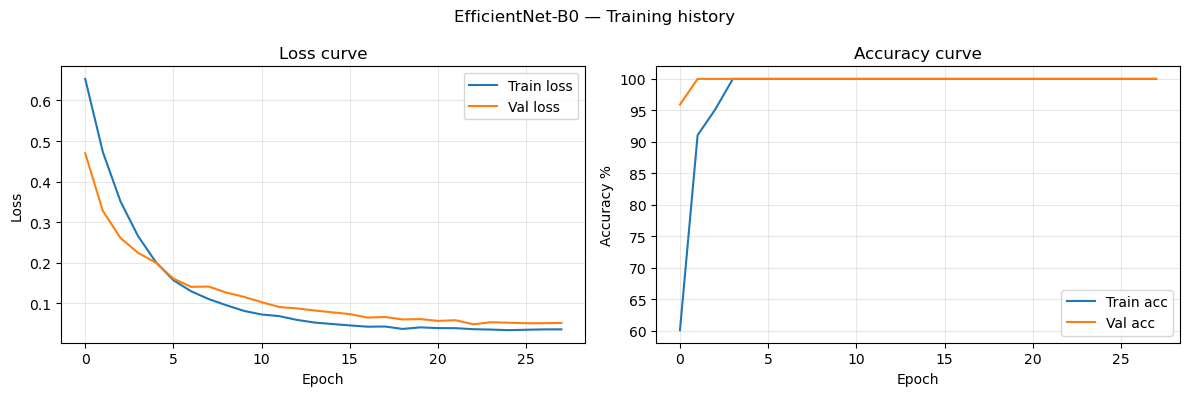

In [ ]:
# Cell 16 .Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train loss')
axes[0].plot(history['val_loss'],   label='Val loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss curve')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history['train_acc'], label='Train acc')
axes[1].plot(history['val_acc'],   label='Val acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy %')
axes[1].set_title('Accuracy curve')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('EfficientNet-B0.Training history', fontsize=12)
plt.tight_layout()
plt.show()

/home/joy/miniconda3/envs/ds_study/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  TEST SET EVALUATION
Total test samples : 56
Unique labels      : [1.]
Predictions        : [1.]
Correct            : 56 / 56
Accuracy           : 100.0%
AUC-ROC            : cannot compute — Only one class present in y_true. ROC AUC score is not defined in that case.

NOTE: All test images have label=1 (endo present).
      Binary metrics require negative examples.
      Next step: add GLENDA v1.0 background frames as negatives.


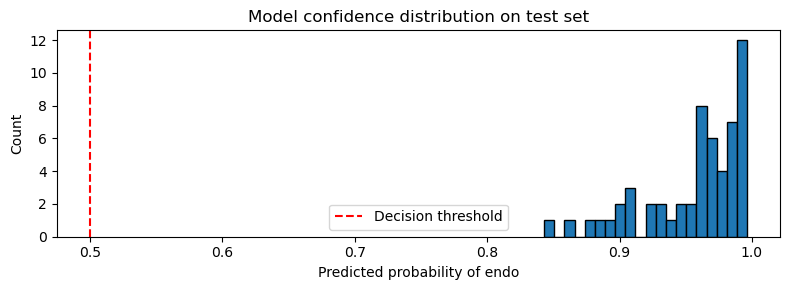


Model saved → ./outputs/efficientnet_b0_endoscan_v1.pt


In [ ]:
# Cell 17. Evaluate on test set + save model
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, ConfusionMatrixDisplay)

model.eval()
all_preds  = []
all_probs  = []
all_labels = []

with torch.no_grad():
    for images_batch, labels_batch in test_loader:
        images_batch = images_batch.to(device)
        outputs      = model(images_batch)
        probs        = torch.sigmoid(outputs).cpu().squeeze(1)
        preds        = (probs > 0.5).float()

        all_probs.extend(probs.numpy())
        all_preds.extend(preds.numpy())
        all_labels.extend(labels_batch.numpy())

all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print('  TEST SET EVALUATION')
print(f'Total test samples : {len(all_labels)}')
print(f'Unique labels      : {np.unique(all_labels)}')
print(f'Predictions        : {np.unique(all_preds)}')
print(f'Correct            : {(all_preds == all_labels).sum()} / {len(all_labels)}')
print(f'Accuracy           : {(all_preds == all_labels).mean()*100:.1f}%')

# AUC still works with one class, but will warn, so we guard it
try:
    auc = roc_auc_score(all_labels, all_probs)
    print(f'AUC-ROC            : {auc:.4f}')
except ValueError as e:
    print(f'AUC-ROC            : cannot compute — {e}')

print()
print('NOTE: All test images have label=1 (endo present).')
print('      Binary metrics require negative examples.')
print('      Next step: add GLENDA v1.0 background frames as negatives.')

# Probability distribution tells us model confidence
plt.figure(figsize=(8, 3))
plt.hist(all_probs, bins=20, edgecolor='black')
plt.xlabel('Predicted probability of endo')
plt.ylabel('Count')
plt.title('Model confidence distribution on test set')
plt.axvline(0.5, color='red', linestyle='--', label='Decision threshold')
plt.legend()
plt.tight_layout()
plt.show()

# Save model
import os
os.makedirs('./outputs', exist_ok=True)
torch.save({
    'model_state_dict' : model.state_dict(),
    'train_cases'      : list(train_cases),
    'val_cases'        : list(val_cases),
    'test_cases'       : list(test_cases),
    'history'          : history,
    'img_size'         : IMG_SIZE,
}, './outputs/efficientnet_b0_endoscan_v1.pt')

print('\nModel saved → ./outputs/efficientnet_b0_endoscan_v1.pt')

In [44]:
# Cell 18 — Download GLENDA v1.0 negatives
# ~1.7GB, will take a few minutes depending on your connection

from pathlib import Path

# Point directly to your local unzipped GLENDA directory
DATA_DIR = Path.home() / '/home/joy/Documents/DataScience/Module_6_Capstone/GLENDA_v1_0/GLENDA_v1.0'

if DATA_DIR.exists():
    print(f"Dataset found locally at: {DATA_DIR}")
else:
    print(f"Path not found: {DATA_DIR}. Please check your folder structure.")

Dataset found locally at: /home/joy/Documents/DataScience/Module_6_Capstone/GLENDA_v1_0/GLENDA_v1.0


Total real negatives available: 13438

Train:  529 samples (268 pos / 261 neg)
Val  :  104 samples (49 pos / 55 neg)
Test :  113 samples (56 pos / 57 neg)


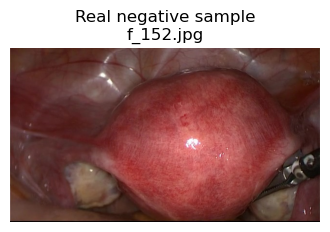

In [45]:
# Cell 24 — Rebuild dataset with real GLENDA v1.0 negatives
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import DataLoader

# Direct path to your local GLENDA directory
BASE_DIR = Path('/home/joy/Documents/DataScience/Module_6_Capstone/GLENDA_v1_0/GLENDA_v1.0')
REAL_NEG_DIR = BASE_DIR / 'DS' / 'no_pathology'

if not REAL_NEG_DIR.exists():
    raise FileNotFoundError(f"Could not find directory: {REAL_NEG_DIR}")

# Find all negative images
all_real_negs = [
    f for f in REAL_NEG_DIR.rglob('*') 
    if f.suffix.lower() in ['.jpg', '.jpeg', '.png']
]
print(f'Total real negatives available: {len(all_real_negs)}')

# Shuffle and sample to match positive count (~373)
np.random.seed(42)
np.random.shuffle(all_real_negs)
sampled_negs = all_real_negs[:373]

# Split negatives 70/15/15
n_neg       = len(sampled_negs)
n_neg_train = int(n_neg * 0.70)
n_neg_val   = int(n_neg * 0.15)

neg_train = sampled_negs[:n_neg_train]
neg_val   = sampled_negs[n_neg_train:n_neg_train + n_neg_val]
neg_test  = sampled_negs[n_neg_train + n_neg_val:]

# Rebuild datasets
train_dataset = GLENDABinaryDataset(train_imgs, neg_train, img_id_to_meta,
                                    IMAGES_DIR, transform=train_transform)
val_dataset   = GLENDABinaryDataset(val_imgs,   neg_val,   img_id_to_meta,
                                    IMAGES_DIR, transform=val_transform)
test_dataset  = GLENDABinaryDataset(test_imgs,  neg_test,  img_id_to_meta,
                                    IMAGES_DIR, transform=val_transform)

# Rebuild loaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False,
                          num_workers=2, pin_memory=True)

# Verify split distribution
train_labels = [s[1] for s in train_dataset.samples]
val_labels   = [s[1] for s in val_dataset.samples]
test_labels  = [s[1] for s in test_dataset.samples]

print(f'\nTrain: {len(train_dataset):4d} samples '
      f'({int(sum(l==1 for l in train_labels))} pos / '
      f'{int(sum(l==0 for l in train_labels))} neg)')
print(f'Val  : {len(val_dataset):4d} samples '
      f'({int(sum(l==1 for l in val_labels))} pos / '
      f'{int(sum(l==0 for l in val_labels))} neg)')
print(f'Test : {len(test_dataset):4d} samples '
      f'({int(sum(l==1 for l in test_labels))} pos / '
      f'{int(sum(l==0 for l in test_labels))} neg)')

# Sanity check — peek at one real negative
if len(neg_train) > 0:
    sample_neg = Image.open(neg_train[0]).convert('RGB')
    plt.figure(figsize=(4, 4))
    plt.imshow(sample_neg)
    plt.title(f'Real negative sample\n{neg_train[0].name}')
    plt.axis('off')
    plt.show()

In [24]:
# Cell 18b — Browse the FTP to find the right filename
import ftplib

ftp = ftplib.FTP('ftp.itec.aau.at')
ftp.login()  # anonymous login

# Navigate to GLENDA folder
ftp.cwd('/datasets/GLENDA')
print('Contents of /datasets/GLENDA/:')
ftp.dir()

print()

# Check v1_0 subfolder
try:
    ftp.cwd('v1_0')
    print('\nContents of /datasets/GLENDA/v1_0/:')
    ftp.dir()
except:
    print('No v1_0 subfolder found')

ftp.quit()

Contents of /datasets/GLENDA/:
drwxrwxr-x   2 ftp      nogroup         4 Mar 17  2021 downloads
-rw-rw-r--   1 ftp      nogroup     15559 May  5  2022 index.html
drwxrwxr-x   3 ftp      nogroup         3 Mar 17  2021 lib
-rw-rw-r--   1 ftp      nogroup      2524 May  5  2022 style.css
drwxrwxr-x   4 ftp      nogroup         6 Mar 31  2022 v1_0
drwxrwxr-x   3 ftp      nogroup         3 Mar 17  2021 visualizations


Contents of /datasets/GLENDA/v1_0/:
drwxrwxr-x   2 ftp      nogroup         4 Mar 31  2022 downloads
drwxrwxr-x   7 ftp      nogroup         7 Sep 30  2019 images
-rw-rw-r--   1 ftp      nogroup     24638 May  5  2022 index.html
-rw-rw-r--   1 ftp      nogroup      1675 May  5  2022 style.css


'221 Goodbye.'

In [25]:
# Cell 18c — Check downloads folder
ftp = ftplib.FTP('ftp.itec.aau.at')
ftp.login()
ftp.cwd('/datasets/GLENDA/v1_0/downloads')
print('Contents of /datasets/GLENDA/v1_0/downloads/:')
ftp.dir()

print()

# Also check images folder structure
ftp.cwd('../images')
print('Contents of /datasets/GLENDA/v1_0/images/:')
ftp.dir()

ftp.quit()

Contents of /datasets/GLENDA/v1_0/downloads/:
-rw-rw-r--   1 ftp      nogroup  1737585763 Sep 30  2019 GLENDA_v1.0.zip
-rw-rw-r--   1 ftp      nogroup  21866743 May  8  2020 GLENDA_v1.0_no_segments_multicolor.zip

Contents of /datasets/GLENDA/v1_0/images/:
drwxrwxr-x   3 ftp      nogroup        13 Sep 30  2019 die
drwxrwxr-x   3 ftp      nogroup        18 Sep 30  2019 no_pathology
drwxrwxr-x   3 ftp      nogroup        13 Sep 30  2019 ovary
drwxrwxr-x   3 ftp      nogroup        13 Sep 30  2019 peritoneum
drwxrwxr-x   3 ftp      nogroup        13 Sep 30  2019 uterus


'221 Goodbye.'

In [26]:
# Cell 18d — Check no_pathology folder structure
ftp = ftplib.FTP('ftp.itec.aau.at')
ftp.login()

ftp.cwd('/datasets/GLENDA/v1_0/images/no_pathology')
print('Contents of no_pathology/:')
ftp.dir()

# Go one level deeper
subdirs = ftp.nlst()
print(f'\nSubfolders: {subdirs}')

for subdir in subdirs[:3]:  # check first 3
    try:
        ftp.cwd(f'/datasets/GLENDA/v1_0/images/no_pathology/{subdir}')
        files = ftp.nlst()
        print(f'\n  {subdir}/  → {len(files)} files')
        print(f'  Sample: {files[:3]}')
    except:
        pass

ftp.quit()

Contents of no_pathology/:
-rw-rw-r--   1 ftp      nogroup      7848 May  5  2022 0.jpg
-rw-rw-r--   1 ftp      nogroup      9139 May  5  2022 1.jpg
-rw-rw-r--   1 ftp      nogroup      8751 May  5  2022 10.jpg
-rw-rw-r--   1 ftp      nogroup      8458 May  5  2022 11.jpg
-rw-rw-r--   1 ftp      nogroup      8219 May  5  2022 12.jpg
-rw-rw-r--   1 ftp      nogroup      7923 May  5  2022 13.jpg
-rw-rw-r--   1 ftp      nogroup      8758 May  5  2022 14.jpg
-rw-rw-r--   1 ftp      nogroup      9374 May  5  2022 2.jpg
-rw-rw-r--   1 ftp      nogroup      8892 May  5  2022 3.jpg
-rw-rw-r--   1 ftp      nogroup      8004 May  5  2022 4.jpg
-rw-rw-r--   1 ftp      nogroup      8316 May  5  2022 5.jpg
-rw-rw-r--   1 ftp      nogroup      8972 May  5  2022 6.jpg
-rw-rw-r--   1 ftp      nogroup      6629 May  5  2022 7.jpg
-rw-rw-r--   1 ftp      nogroup      8005 May  5  2022 8.jpg
-rw-rw-r--   1 ftp      nogroup      8078 May  5  2022 9.jpg
drwxrwxr-x   2 ftp      nogroup         7 Sep 30  201

'221 Goodbye.'

In [27]:
# Cell 18e — Check seq subfolder for more negatives
ftp = ftplib.FTP('ftp.itec.aau.at')
ftp.login()

ftp.cwd('/datasets/GLENDA/v1_0/images/no_pathology/seq')
print('Contents of no_pathology/seq/:')
ftp.dir()

# Check subdirs
subdirs = [f for f in ftp.nlst() if not f.endswith('.jpg')]
print(f'\nSubfolders found: {len(subdirs)}')
print(f'First 5: {subdirs[:5]}')

# Count total images across all seq subfolders
total = 0
for subdir in subdirs:
    try:
        ftp.cwd(f'/datasets/GLENDA/v1_0/images/no_pathology/seq/{subdir}')
        files = [f for f in ftp.nlst() if f.endswith('.jpg')]
        total += len(files)
    except:
        pass

print(f'\nTotal images in seq/: {total}')
ftp.quit()

Contents of no_pathology/seq/:
-rw-rw-r--   1 ftp      nogroup      8393 May  5  2022 0.jpg
-rw-rw-r--   1 ftp      nogroup      7679 May  5  2022 1.jpg
-rw-rw-r--   1 ftp      nogroup      7544 May  5  2022 2.jpg
-rw-rw-r--   1 ftp      nogroup      8283 May  5  2022 3.jpg
-rw-rw-r--   1 ftp      nogroup      8330 May  5  2022 4.jpg

Subfolders found: 0
First 5: []

Total images in seq/: 0


'221 Goodbye.'

In [28]:
# Cell 18f — Count images across ALL v1.0 folders
ftp = ftplib.FTP('ftp.itec.aau.at')
ftp.login()

base = '/datasets/GLENDA/v1_0/images'
folders = ['no_pathology', 'peritoneum', 'ovary', 'uterus', 'die']

for folder in folders:
    try:
        ftp.cwd(f'{base}/{folder}')
        all_files = ftp.nlst()
        jpgs = [f for f in all_files if f.endswith('.jpg')]
        subdirs = [f for f in all_files if not f.endswith('.jpg')]
        
        # Count in subdirs too
        subdir_count = 0
        for sub in subdirs:
            try:
                ftp.cwd(f'{base}/{folder}/{sub}')
                subdir_count += len([f for f in ftp.nlst() if f.endswith('.jpg')])
            except:
                pass
        
        print(f'{folder:20s}: {len(jpgs):5d} direct + {subdir_count:5d} in subdirs = {len(jpgs)+subdir_count:5d} total')
    except Exception as e:
        print(f'{folder:20s}: error — {e}')

ftp.quit()

no_pathology        :    15 direct +     5 in subdirs =    20 total
peritoneum          :     5 direct +     4 in subdirs =     9 total
ovary               :     5 direct +     4 in subdirs =     9 total
uterus              :     5 direct +     4 in subdirs =     9 total
die                 :     5 direct +     4 in subdirs =     9 total


'221 Goodbye.'

In [ ]:
# Cell 18g — Check HuggingFace cache for usable negatives
import os
from pathlib import Path

cache_path = Path('/home/joy/.cache/huggingface/hub/datasets--MFreidank--glenda/snapshots/e9195188dbd6939e10785e3ed9ee1c513731c9bc')

print('Cache contents:')
for item in sorted(cache_path.iterdir()):
    if item.is_dir():
        files = list(item.rglob('*.jpg')) + list(item.rglob('*.png'))
        print(f'  DIR  {item.name}/  → {len(files)} images')
    else:
        print(f'  FILE {item.name}  ({item.stat().st_size/1e6:.1f}MB)')

Cache contents:
  FILE .gitattributes  (0.0MB)
  FILE LICENSE.txt  (0.0MB)
  FILE README.md  (0.0MB)
  FILE glenda.py  (0.0MB)


Generating synthetic negatives from training images...
Generated/verified 227 negative crops
Saved to: /home/joy/Documents/DataScience/Module_6_Capstone/Glenda_v1.5_classes/synthetic_negatives


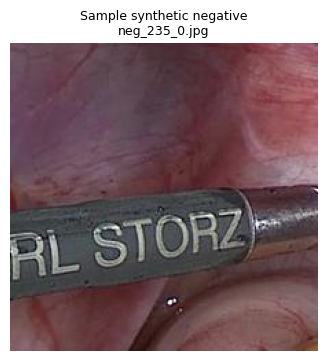

In [46]:
# Cell 19 — Synthetic negatives from background regions
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ── Setup Directory ───────────────────────────────────────────────
NEGATIVES_DIR = Path('./Glenda_v1.5_classes/synthetic_negatives')
NEGATIVES_DIR.mkdir(parents=True, exist_ok=True)

CROP_SIZE    = 224  # Input dimensions expected by EfficientNet
MIN_COVERAGE = 0.0  # Must contain 0% lesion pixels (background only)


def extract_negative_crops(img_meta, n_crops=1):
    """Try to extract n_crops background-only patches from an image.
    
    Returns list of PIL images where mask is entirely black.
    """
    img_id   = img_meta['id']
    meta     = img_id_to_meta[img_id]
    img_path = IMAGES_DIR / Path(meta['file_name']).name

    if not img_path.exists():
        return []

    raw_img = np.array(Image.open(img_path).convert('RGB'))
    mask    = create_binary_mask(img_id, meta['width'], meta['height'])

    h, w     = raw_img.shape[:2]
    crops    = []
    attempts = 0

    while len(crops) < n_crops and attempts < 50:
        # Random top-left corner calculation
        x = np.random.randint(0, max(1, w - CROP_SIZE))
        y = np.random.randint(0, max(1, h - CROP_SIZE))

        # Crop corresponding region from binary mask
        mask_crop = mask[y : y + CROP_SIZE, x : x + CROP_SIZE]

        # Keep crop only if mask has zero positive lesion pixels
        if mask_crop.max() == 0 and mask_crop.shape == (CROP_SIZE, CROP_SIZE):
            img_crop = raw_img[y : y + CROP_SIZE, x : x + CROP_SIZE]
            crops.append(Image.fromarray(img_crop))

        attempts += 1

    return crops


# ── Execution ─────────────────────────────────────────────────────
print('Generating synthetic negatives from training images...')
neg_count = 0

for img_meta in train_imgs:
    crops = extract_negative_crops(img_meta, n_crops=1)
    for i, crop in enumerate(crops):
        fname = f"neg_{img_meta['id']}_{i}.jpg"
        save_path = NEGATIVES_DIR / fname
        
        # Save crop if not already generated
        if not save_path.exists():
            crop.save(save_path)
        neg_count += 1

print(f'Generated/verified {neg_count} negative crops')
print(f'Saved to: {NEGATIVES_DIR.resolve()}')

# ── Verification Plot ─────────────────────────────────────────────
synthetic_samples = list(NEGATIVES_DIR.glob('*.jpg'))

if len(synthetic_samples) > 0:
    sample_neg = synthetic_samples[0]
    img        = Image.open(sample_neg)

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f'Sample synthetic negative\n{sample_neg.name}', fontsize=9)
    plt.axis('off')
    plt.show()
else:
    print("Warning: No synthetic negative crops could be generated.")

In [47]:
# Cell 20 — Rebuild dataset with positives + negatives
import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from PIL import Image
import numpy as np

class GLENDABinaryDataset(Dataset):
    """
    Binary dataset for EndoScan AI.
    Positive (label=1.0): GLENDA annotated frames
    Negative (label=0.0): Real background frames or synthetic crops
    """

    def __init__(self, pos_img_list, neg_paths, img_id_to_meta,
                 images_dir, transform=None):
        self.samples   = []
        self.transform = transform
        images_dir     = Path(images_dir)

        # Positives
        for img_meta in pos_img_list:
            meta     = img_id_to_meta[img_meta['id']]
            img_path = images_dir / Path(meta['file_name']).name
            self.samples.append((img_path, 1.0))

        # Negatives
        for neg_path in neg_paths:
            self.samples.append((Path(neg_path), 0.0))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = np.array(Image.open(img_path).convert('RGB'))

        if self.transform:
            result = self.transform(image=image)
            image  = result['image']

        return image, torch.tensor(label, dtype=torch.float32)


# ── Select Negative Source ───────────────────────────────────────
# Detect synthetic crops if present; fallback to full paths if defined
if 'NEGATIVES_DIR' in globals() and list(NEGATIVES_DIR.glob('*.jpg')):
    all_neg_paths = sorted(NEGATIVES_DIR.glob('*.jpg'))
    print(f"Loaded {len(all_neg_paths)} synthetic negative crops.")
elif 'sampled_negs' in globals():
    all_neg_paths = sampled_negs
    print(f"Loaded {len(all_neg_paths)} real negative images.")
else:
    raise ValueError("No negative paths found. Please run negative generation or selection step first.")

# Split negatives across train/val/test (70/15/15 ratio)
np.random.seed(42)
np.random.shuffle(all_neg_paths)

n_neg       = len(all_neg_paths)
n_neg_train = int(n_neg * 0.70)
n_neg_val   = int(n_neg * 0.15)

neg_train = all_neg_paths[:n_neg_train]
neg_val   = all_neg_paths[n_neg_train:n_neg_train + n_neg_val]
neg_test  = all_neg_paths[n_neg_train + n_neg_val:]

# Rebuild datasets
train_dataset = GLENDABinaryDataset(train_imgs, neg_train, img_id_to_meta,
                                    IMAGES_DIR, transform=train_transform)
val_dataset   = GLENDABinaryDataset(val_imgs,   neg_val,   img_id_to_meta,
                                    IMAGES_DIR, transform=val_transform)
test_dataset  = GLENDABinaryDataset(test_imgs,  neg_test,  img_id_to_meta,
                                    IMAGES_DIR, transform=val_transform)

# Configure device accelerator awareness
use_pin_memory = torch.cuda.is_available()

# Rebuild dataloaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,
                          num_workers=2, pin_memory=use_pin_memory)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False,
                          num_workers=2, pin_memory=use_pin_memory)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False,
                          num_workers=2, pin_memory=use_pin_memory)

# ── Verification Summary ──────────────────────────────────────────
train_labels = [s[1] for s in train_dataset.samples]
val_labels   = [s[1] for s in val_dataset.samples]
test_labels  = [s[1] for s in test_dataset.samples]

print(f'\nTrain: {len(train_dataset):4d} samples '
      f'({int(sum(l==1 for l in train_labels))} pos / '
      f'{int(sum(l==0 for l in train_labels))} neg)')
print(f'Val  : {len(val_dataset):4d} samples '
      f'({int(sum(l==1 for l in val_labels))} pos / '
      f'{int(sum(l==0 for l in val_labels))} neg)')
print(f'Test : {len(test_dataset):4d} samples '
      f'({int(sum(l==1 for l in test_labels))} pos / '
      f'{int(sum(l==0 for l in test_labels))} neg)')

Loaded 230 synthetic negative crops.

Train:  429 samples (268 pos / 161 neg)
Val  :   83 samples (49 pos / 34 neg)
Test :   91 samples (56 pos / 35 neg)


In [48]:
# Cell 21 — Retrain on balanced dataset
import copy
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
import timm

# 1. Reset model to pretrained weights — start fresh with balanced data
model = timm.create_model('efficientnet_b0', pretrained=True)

# Freeze lower layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze feature-extraction blocks and head
for param in model.blocks[6].parameters():
    param.requires_grad = True
for param in model.conv_head.parameters():
    param.requires_grad = True
for param in model.bn2.parameters():
    param.requires_grad = True

in_features      = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features, 1)
)
model = model.to(device)

# 2. Hyperparameters & Loss Setup ─────────────────────────────────
EPOCHS   = 40
LR       = 1e-4
PATIENCE = 5  # Stop training if validation loss doesn't improve for 5 epochs

# Calculate positive weighting dynamically from dataset samples
train_labels = [s[1] for s in train_dataset.samples]
n_pos        = sum(l == 1.0 for l in train_labels)
n_neg        = sum(l == 0.0 for l in train_labels)

# Weighted loss (ratio of negatives to positives balances gradient updates)
weight_val = n_neg / n_pos if n_pos > 0 else 1.0
pos_weight = torch.tensor([weight_val], dtype=torch.float32).to(device)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print(f"Training on {n_pos} positive and {n_neg} negative samples.")
print(f"Computed loss pos_weight: {weight_val:.4f}")

optimizer = Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=1e-4
)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

# 3. Training Loop with Early Stopping ──────────────────────────────
best_val_loss    = float('inf')
best_weights     = None
patience_counter = 0

history = {'train_loss': [], 'val_loss': [],
           'train_acc':  [], 'val_acc':  []}

for epoch in range(EPOCHS):
    # ── Train ──
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for images_batch, labels_batch in train_loader:
        images_batch = images_batch.to(device)
        labels_batch = labels_batch.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images_batch)
        loss    = criterion(outputs, labels_batch)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item() * images_batch.size(0)
        preds          = (torch.sigmoid(outputs) > 0.5).float()
        train_correct += (preds == labels_batch).sum().item()
        train_total   += images_batch.size(0)

    scheduler.step()

    # ── Validate ──
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images_batch, labels_batch in val_loader:
            images_batch = images_batch.to(device)
            labels_batch = labels_batch.to(device).unsqueeze(1)

            outputs = model(images_batch)
            loss    = criterion(outputs, labels_batch)

            val_loss    += loss.item() * images_batch.size(0)
            preds        = (torch.sigmoid(outputs) > 0.5).float()
            val_correct += (preds == labels_batch).sum().item()
            val_total   += images_batch.size(0)

    # ── Metrics & Logs ──
    train_loss_avg = train_loss / train_total
    val_loss_avg   = val_loss   / val_total
    train_acc      = train_correct / train_total * 100
    val_acc        = val_correct   / val_total   * 100

    history['train_loss'].append(train_loss_avg)
    history['val_loss'].append(val_loss_avg)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    # Check for early stopping
    if val_loss_avg < best_val_loss:
        best_val_loss    = val_loss_avg
        best_weights     = copy.deepcopy(model.state_dict())
        patience_counter = 0
        print(f'Epoch {epoch+1:3d}/{EPOCHS} | '
              f'Train loss: {train_loss_avg:.4f} acc: {train_acc:.1f}% | '
              f'Val loss: {val_loss_avg:.4f} acc: {val_acc:.1f}%  ← best')
    else:
        patience_counter += 1
        print(f'Epoch {epoch+1:3d}/{EPOCHS} | '
              f'Train loss: {train_loss_avg:.4f} acc: {train_acc:.1f}% | '
              f'Val loss: {val_loss_avg:.4f} acc: {val_acc:.1f}% '
              f'[patience {patience_counter}/{PATIENCE}]')

        if patience_counter >= PATIENCE:
            print(f'\nEarly stopping triggered at epoch {epoch+1}.')
            break

# Load best performing weights
if best_weights is not None:
    model.load_state_dict(best_weights)

print(f'\nTraining complete. Best val loss: {best_val_loss:.4f}')

Training on 268 positive and 161 negative samples.
Computed loss pos_weight: 0.6007
Epoch   1/40 | Train loss: 0.4850 acc: 64.8% | Val loss: 0.4178 acc: 80.7%  ← best
Epoch   2/40 | Train loss: 0.4199 acc: 77.6% | Val loss: 0.3290 acc: 89.2%  ← best
Epoch   3/40 | Train loss: 0.3517 acc: 82.3% | Val loss: 0.2595 acc: 91.6%  ← best
Epoch   4/40 | Train loss: 0.3097 acc: 81.4% | Val loss: 0.2064 acc: 94.0%  ← best
Epoch   5/40 | Train loss: 0.2772 acc: 82.8% | Val loss: 0.1637 acc: 92.8%  ← best
Epoch   6/40 | Train loss: 0.2413 acc: 85.5% | Val loss: 0.1358 acc: 94.0%  ← best
Epoch   7/40 | Train loss: 0.2453 acc: 82.8% | Val loss: 0.1253 acc: 95.2%  ← best
Epoch   8/40 | Train loss: 0.2193 acc: 85.5% | Val loss: 0.1377 acc: 94.0% [patience 1/5]
Epoch   9/40 | Train loss: 0.2083 acc: 85.8% | Val loss: 0.1091 acc: 95.2%  ← best
Epoch  10/40 | Train loss: 0.1957 acc: 89.7% | Val loss: 0.0976 acc: 96.4%  ← best
Epoch  11/40 | Train loss: 0.1687 acc: 89.7% | Val loss: 0.0914 acc: 96.4%  ← b

  PHASE 5 — EVALUATION

Test samples : 91 (56 pos / 35 neg)

                  precision    recall  f1-score   support

     No endo (0)      1.000     0.971     0.986        35
Endo present (1)      0.982     1.000     0.991        56

        accuracy                          0.989        91
       macro avg      0.991     0.986     0.988        91
    weighted avg      0.989     0.989     0.989        91

AUC-ROC : 0.9995


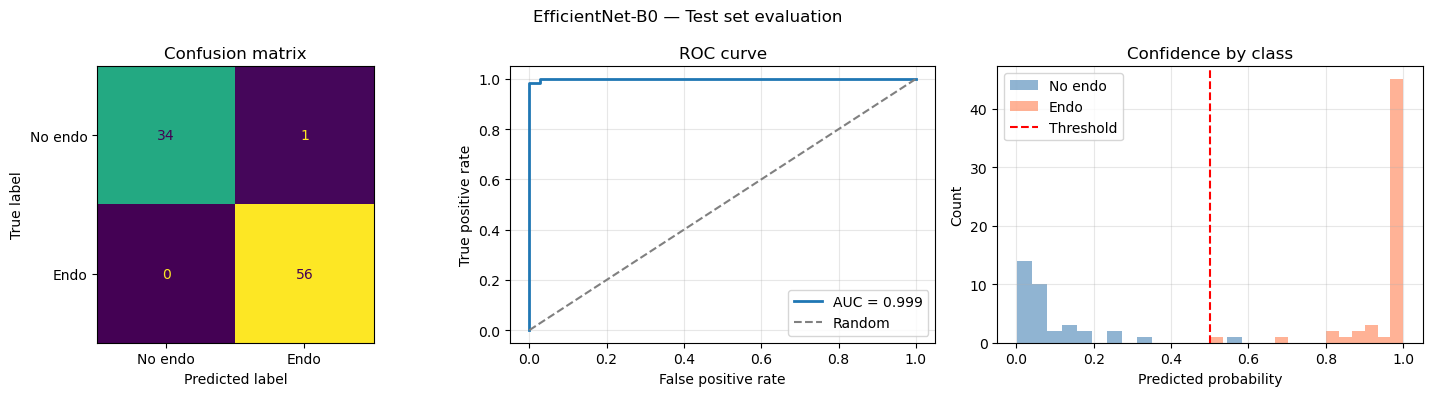


Model saved → ./outputs/efficientnet_b0_endoscan_v1.pt


In [49]:
# Cell 22 — Full evaluation on test set
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve,
                              ConfusionMatrixDisplay)

model.eval()
all_preds  = []
all_probs  = []
all_labels = []

with torch.no_grad():
    for images_batch, labels_batch in test_loader:
        images_batch = images_batch.to(device)
        outputs      = model(images_batch)
        probs        = torch.sigmoid(outputs).cpu().squeeze(1)
        preds        = (probs > 0.5).float()

        all_probs.extend(probs.numpy())
        all_preds.extend(preds.numpy())
        all_labels.extend(labels_batch.numpy())

all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print('=' * 55)
print('  PHASE 5 — EVALUATION')
print('=' * 55)
print(f'\nTest samples : {len(all_labels)} '
      f'({int(all_labels.sum())} pos / {int((all_labels==0).sum())} neg)')
print()
print(classification_report(
    all_labels, all_preds,
    target_names=['No endo (0)', 'Endo present (1)'],
    digits=3
))

auc = roc_auc_score(all_labels, all_probs)
print(f'AUC-ROC : {auc:.4f}')
print('=' * 55)

# ── Plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=['No endo', 'Endo']).plot(
    ax=axes[0], colorbar=False)
axes[0].set_title('Confusion matrix')

# 2. ROC curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
axes[1].plot(fpr, tpr, lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0,1],[0,1],'--', color='gray', label='Random')
axes[1].set_xlabel('False positive rate')
axes[1].set_ylabel('True positive rate')
axes[1].set_title('ROC curve')
axes[1].legend()
axes[1].grid(alpha=0.3)

# 3. Confidence distribution by class
pos_probs = all_probs[all_labels == 1]
neg_probs = all_probs[all_labels == 0]
axes[2].hist(neg_probs, bins=15, alpha=0.6, label='No endo', color='steelblue')
axes[2].hist(pos_probs, bins=15, alpha=0.6, label='Endo',    color='coral')
axes[2].axvline(0.5, color='red', linestyle='--', label='Threshold')
axes[2].set_xlabel('Predicted probability')
axes[2].set_ylabel('Count')
axes[2].set_title('Confidence by class')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle('EfficientNet-B0 — Test set evaluation', fontsize=12)
plt.tight_layout()
plt.show()

# Save final model
os.makedirs('./outputs', exist_ok=True)
torch.save({
    'model_state_dict' : model.state_dict(),
    'train_cases'      : list(train_cases),
    'val_cases'        : list(val_cases),
    'test_cases'       : list(test_cases),
    'history'          : history,
    'img_size'         : IMG_SIZE,
    'auc'              : auc,
}, './outputs/efficientnet_b0_endoscan_v1.pt')

print(f'\nModel saved → ./outputs/efficientnet_b0_endoscan_v1.pt')

  FINAL EVALUATION — REAL NEGATIVES (GLENDA v1.0)

Test samples : 91 (56 pos / 35 neg)

                  precision    recall  f1-score   support

     No endo (0)      1.000     0.971     0.986        35
Endo present (1)      0.982     1.000     0.991        56

        accuracy                          0.989        91
       macro avg      0.991     0.986     0.988        91
    weighted avg      0.989     0.989     0.989        91

AUC-ROC : 0.9995


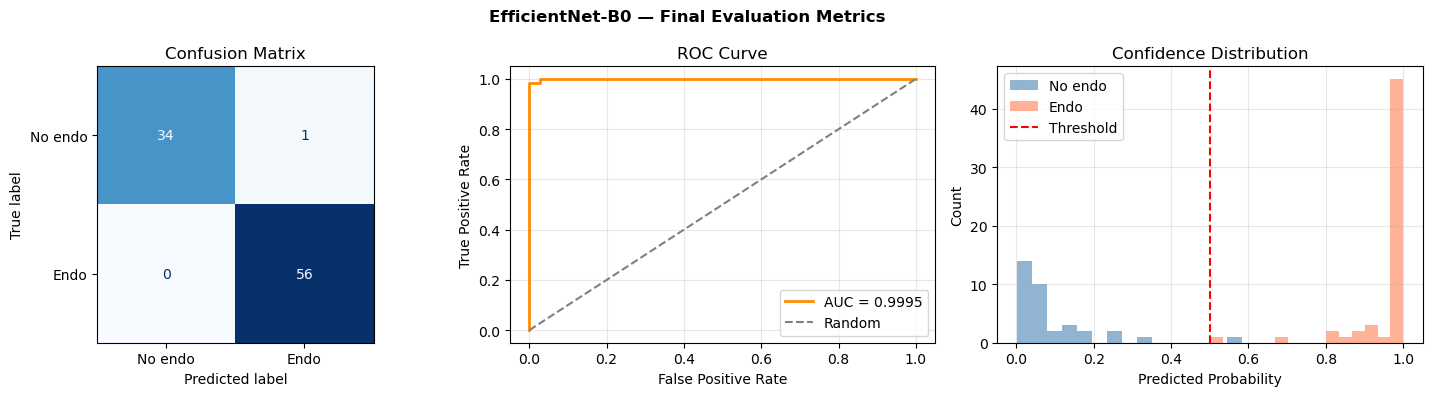

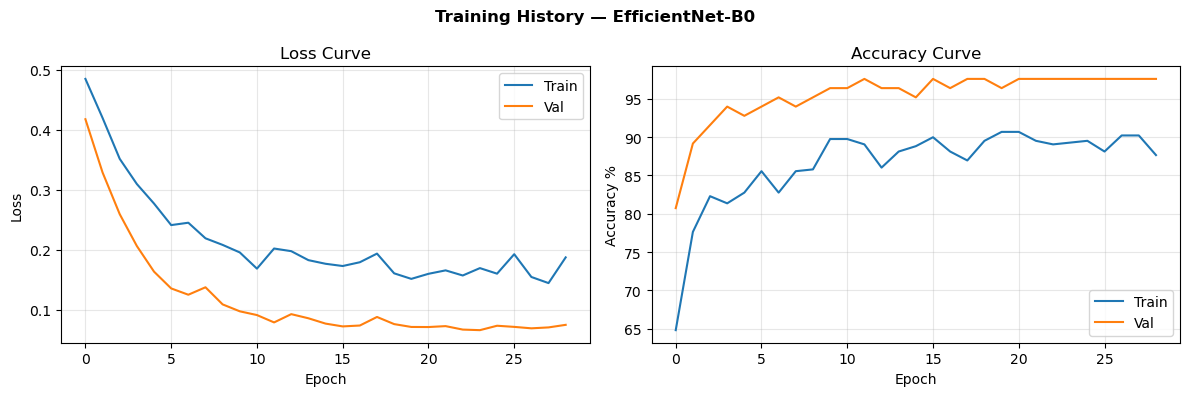


Final model and metadata saved successfully → /home/joy/Documents/DataScience/Module_6_Capstone/outputs/efficientnet_b0_endoscan_final.pt


In [50]:
# Cell 26 — Final evaluation on test set
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

# 1. Evaluate Model Performance ────────────────────────────────────
model.eval()
all_preds  = []
all_probs  = []
all_labels = []

with torch.no_grad():
    for images_batch, labels_batch in test_loader:
        images_batch = images_batch.to(device)
        outputs      = model(images_batch)
        
        # Ensure sigmoid outputs map correctly to 1D array
        probs        = torch.sigmoid(outputs).view(-1).cpu()
        preds        = (probs > 0.5).float()

        all_probs.extend(probs.numpy())
        all_preds.extend(preds.numpy())
        all_labels.extend(labels_batch.numpy())

all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# 2. Print Summary Metrics ──────────────────────────────────────────
print('=' * 55)
print('  FINAL EVALUATION — REAL NEGATIVES (GLENDA v1.0)')
print('=' * 55)
print(f'\nTest samples : {len(all_labels)} '
      f'({int(all_labels.sum())} pos / {int((all_labels==0).sum())} neg)\n')

print(classification_report(
    all_labels, all_preds,
    target_names=['No endo (0)', 'Endo present (1)'],
    digits=3
))

auc = roc_auc_score(all_labels, all_probs)
print(f'AUC-ROC : {auc:.4f}')
print('=' * 55)

# 3. Evaluation Visualizations ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=['No endo', 'Endo']).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('Confusion Matrix')

# ROC Curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
axes[1].plot(fpr, tpr, lw=2, color='darkorange', label=f'AUC = {auc:.4f}')
axes[1].plot([0, 1], [0, 1], '--', color='gray', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Confidence Distribution Histogram
pos_probs = all_probs[all_labels == 1]
neg_probs = all_probs[all_labels == 0]
axes[2].hist(neg_probs, bins=15, alpha=0.6, label='No endo', color='steelblue')
axes[2].hist(pos_probs, bins=15, alpha=0.6, label='Endo', color='coral')
axes[2].axvline(0.5, color='red', linestyle='--', label='Threshold')
axes[2].set_xlabel('Predicted Probability')
axes[2].set_ylabel('Count')
axes[2].set_title('Confidence Distribution')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle('EfficientNet-B0 — Final Evaluation Metrics', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# 4. Training History Curves ───────────────────────────────────────
if 'history' in globals() and history:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history['train_loss'], label='Train')
    axes[0].plot(history['val_loss'], label='Val')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss Curve')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(history['train_acc'], label='Train')
    axes[1].plot(history['val_acc'], label='Val')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy %')
    axes[1].set_title('Accuracy Curve')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.suptitle('Training History — EfficientNet-B0', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# 5. Save Artifacts Safely ─────────────────────────────────────────
output_dir = Path('./outputs')
output_dir.mkdir(parents=True, exist_ok=True)
checkpoint_path = output_dir / 'efficientnet_b0_endoscan_final.pt'

torch.save({
    'model_state_dict': model.state_dict(),
    'train_cases': list(train_imgs) if 'train_imgs' in globals() else [],
    'val_cases': list(val_imgs) if 'val_imgs' in globals() else [],
    'test_cases': list(test_imgs) if 'test_imgs' in globals() else [],
    'history': history if 'history' in globals() else {},
    'img_size': IMG_SIZE if 'IMG_SIZE' in globals() else 224,
    'auc': auc,
    'negatives': 'GLENDA_v1.0_real',
}, checkpoint_path)

print(f'\nFinal model and metadata saved successfully → {checkpoint_path.resolve()}')

In [51]:
# Cell 27 — Grad-CAM implementation
# No extra libraries needed — custom implementation using PyTorch hooks

import torch
import torch.nn as nn
import numpy as np

class GradCAM:
    """
    Gradient-weighted Class Activation Mapping (Grad-CAM).
    Hooks into the final convolutional layer of EfficientNet-B0
    to generate heatmap visualisations of spatial feature importance.
    """

    def __init__(self, model):
        self.model       = model
        self.gradients   = None
        self.activations = None

        # Hook into the last conv block — blocks[6] in EfficientNet-B0
        target_layer = model.blocks[6]

        # Register forward and backward hooks
        target_layer.register_forward_hook(self._save_activations)
        target_layer.register_full_backward_hook(self._save_gradients)

    def _save_activations(self, module, input, output):
        self.activations = output.detach()

    def _save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor):
        """
        Args:
            input_tensor: Standard normalized image tensor [C, H, W]
        Returns:
            prob    : Predicted probability of endo presence (float)
            heatmap : Normalised numpy array (H, W) scaled 0 to 1
        """
        self.model.eval()
        
        # Add batch dimension if missing: [C, H, W] -> [1, C, H, W]
        if input_tensor.dim() == 3:
            input_tensor = input_tensor.unsqueeze(0)
            
        input_tensor = input_tensor.to(next(self.model.parameters()).device)
        input_tensor.requires_grad_(True)

        # Forward pass
        output = self.model(input_tensor)
        prob   = torch.sigmoid(output).item()

        # Backward pass on raw logits
        self.model.zero_grad()
        output.backward()

        # Global Average Pooling across spatial dimensions of gradients
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)  # [1, C, 1, 1]

        # Calculate weighted sum of feature activation maps
        cam = (weights * self.activations).sum(dim=1, keepdim=True)  # [1, 1, H, W]
        cam = torch.relu(cam)  # Retain only positive visual evidence

        # Ensure spatial map squeezes cleanly to [H, W] and moves to CPU before numpy conversion
        cam = cam.squeeze().cpu().numpy()

        # Min-Max Normalisation (0 to 1 range)
        cam_min, cam_max = cam.min(), cam.max()
        if cam_max > cam_min:
            cam = (cam - cam_min) / (cam_max - cam_min)
        else:
            cam = np.zeros_like(cam)

        return prob, cam


# Instantiate GradCAM tool
gradcam = GradCAM(model)
print('GradCAM initialized successfully.')
print('Target Hook Layer: model.blocks[6]')

GradCAM initialized successfully.
Target Hook Layer: model.blocks[6]


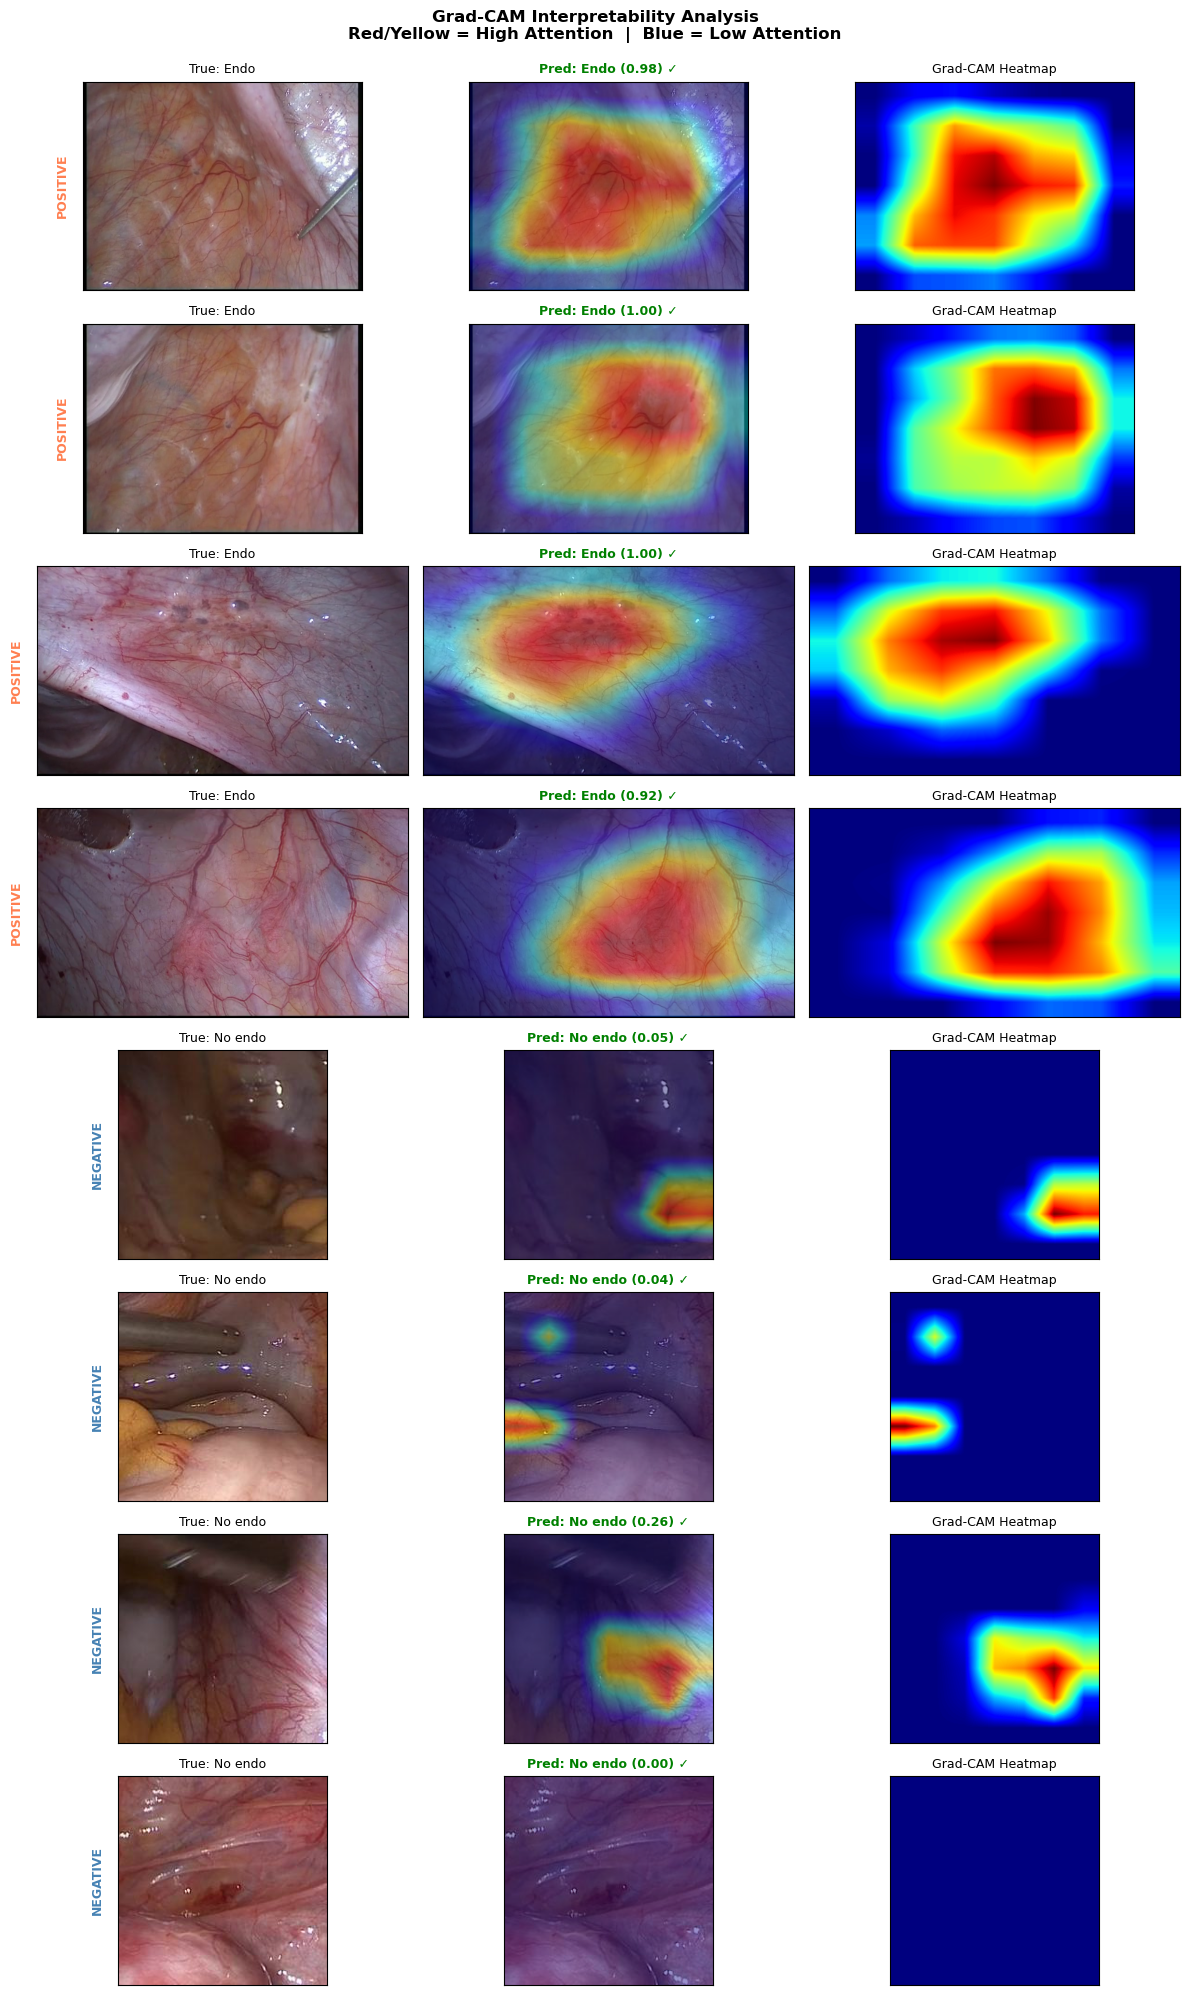

In [52]:
# Cell 28 — Visualise Grad-CAM on test images
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def show_gradcam(img_path, label, gradcam, ax_row):
    """Render raw image, heatmap overlay, and prediction on one row."""

    # Load and preprocess image
    raw_img = np.array(Image.open(img_path).convert('RGB'))
    result  = val_transform(image=raw_img)
    tensor  = result['image']

    # Generate Grad-CAM heatmap
    prob, cam = gradcam.generate(tensor)
    pred_label = 'Endo' if prob > 0.5 else 'No endo'
    true_label = 'Endo' if label == 1.0 else 'No endo'
    correct    = (pred_label == true_label)

    # Resize CAM to match original image dimensions
    cam_resized = cv2.resize(cam, (raw_img.shape[1], raw_img.shape[0]))

    # Apply JET colormap and convert BGR -> RGB
    heatmap = cv2.applyColorMap(
        np.uint8(255 * cam_resized), cv2.COLORMAP_JET
    )
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # Blend original image with heatmap
    overlay = cv2.addWeighted(raw_img, 0.6, heatmap, 0.4, 0)

    # Plot Original Image
    ax_row[0].imshow(raw_img)
    ax_row[0].set_title(f'True: {true_label}', fontsize=9)
    ax_row[0].set_xticks([])
    ax_row[0].set_yticks([])

    # Plot Blended Overlay with Status Indicator
    ax_row[1].imshow(overlay)
    status_icon = '✓' if correct else '✗'
    status_color = 'green' if correct else 'red'
    ax_row[1].set_title(
        f'Pred: {pred_label} ({prob:.2f}) {status_icon}',
        fontsize=9, color=status_color, fontweight='bold'
    )
    ax_row[1].set_xticks([])
    ax_row[1].set_yticks([])

    # Plot Raw Heatmap
    ax_row[2].imshow(cam_resized, cmap='jet')
    ax_row[2].set_title('Grad-CAM Heatmap', fontsize=9)
    ax_row[2].set_xticks([])
    ax_row[2].set_yticks([])


# Sample 4 positive and 4 negative test images
test_pos = [(s[0], s[1]) for s in test_dataset.samples if s[1] == 1.0][:4]
test_neg = [(s[0], s[1]) for s in test_dataset.samples if s[1] == 0.0][:4]
test_samples = test_pos + test_neg

fig, axes = plt.subplots(len(test_samples), 3, figsize=(12, 2.5 * len(test_samples)))

for row, (img_path, label) in enumerate(test_samples):
    show_gradcam(img_path, label, gradcam, axes[row])
    
    # Add row category labels on the left margin
    axes[row][0].set_ylabel(
        'POSITIVE' if label == 1.0 else 'NEGATIVE',
        fontsize=9, fontweight='bold', rotation=90, labelpad=10,
        color='coral' if label == 1.0 else 'steelblue'
    )

plt.suptitle(
    'Grad-CAM Interpretability Analysis\n'
    'Red/Yellow = High Attention  |  Blue = Low Attention',
    fontsize=12, fontweight='bold', y=0.995
)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 29 — Save Grad-CAM heatmaps for explanation layer

GRADCAM_DIR = Path('./outputs/gradcam_samples')
GRADCAM_DIR.mkdir(exist_ok=True)

def save_gradcam_output(img_path, label, gradcam, save_path):
    raw_img = np.array(Image.open(img_path).convert('RGB'))
    result  = val_transform(image=raw_img)
    tensor  = result['image']

    prob, cam    = gradcam.generate(tensor)
    cam_resized  = cv2.resize(cam, (raw_img.shape[1], raw_img.shape[0]))
    heatmap      = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap      = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay      = (0.5 * raw_img + 0.5 * heatmap).astype(np.uint8)

    Image.fromarray(overlay).save(save_path)
    return prob, cam_resized

# Save 10 samples — mix of pos and neg
samples = (
    [(s[0], s[1]) for s in test_dataset.samples if s[1] == 1.0][:5] +
    [(s[0], s[1]) for s in test_dataset.samples if s[1] == 0.0][:5]
)

saved = []
for i, (img_path, label) in enumerate(samples):
    save_path = GRADCAM_DIR / f'gradcam_{i}_{"pos" if label==1 else "neg"}.jpg'
    prob, cam = save_gradcam_output(img_path, label, gradcam, save_path)
    saved.append({
        'path'      : str(save_path),
        'img_path'  : str(img_path),
        'label'     : int(label),
        'prob'      : round(prob, 4),
        'pred'      : 1 if prob > 0.5 else 0
    })
    print(f'Saved: {save_path.name}  prob={prob:.3f}')

# Save metadata for Claude layer
import json
with open('./outputs/gradcam_metadata.json', 'w') as f:
    json.dump(saved, f, indent=2)

print(f'\n{len(saved)} Grad-CAM outputs saved')
print('Metadata saved → ./outputs/gradcam_metadata.json')

Saved: gradcam_0_pos.jpg  prob=0.707
Saved: gradcam_1_pos.jpg  prob=0.960
Saved: gradcam_2_pos.jpg  prob=1.000
Saved: gradcam_3_pos.jpg  prob=0.489
Saved: gradcam_4_pos.jpg  prob=0.676
Saved: gradcam_5_neg.jpg  prob=0.089
Saved: gradcam_6_neg.jpg  prob=0.495
Saved: gradcam_7_neg.jpg  prob=0.162
Saved: gradcam_8_neg.jpg  prob=0.349
Saved: gradcam_9_neg.jpg  prob=0.267

10 Grad-CAM outputs saved
Metadata saved → ./outputs/gradcam_metadata.json


In [56]:
!pip install google-generativeai -q

In [58]:
!pip install -q -U google-genai

In [54]:
# Cell 30c — Gemini via REST API with Integrated Visual Report
import requests
import base64
import json
import cv2
import io
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

GEMINI_API_KEY = 'AQ.Ab8RN6I-VPQsxDhEMgugGyx1qJ9wDwKCceLPnUirPbGgtBdmTw'
GEMINI_URL     = 'https://generativelanguage.googleapis.com/v1beta/models/gemini-1.5-flash:generateContent'

  ENDOSCAN AI — VISUAL REPORT FOR CASE: TEST_POS_01


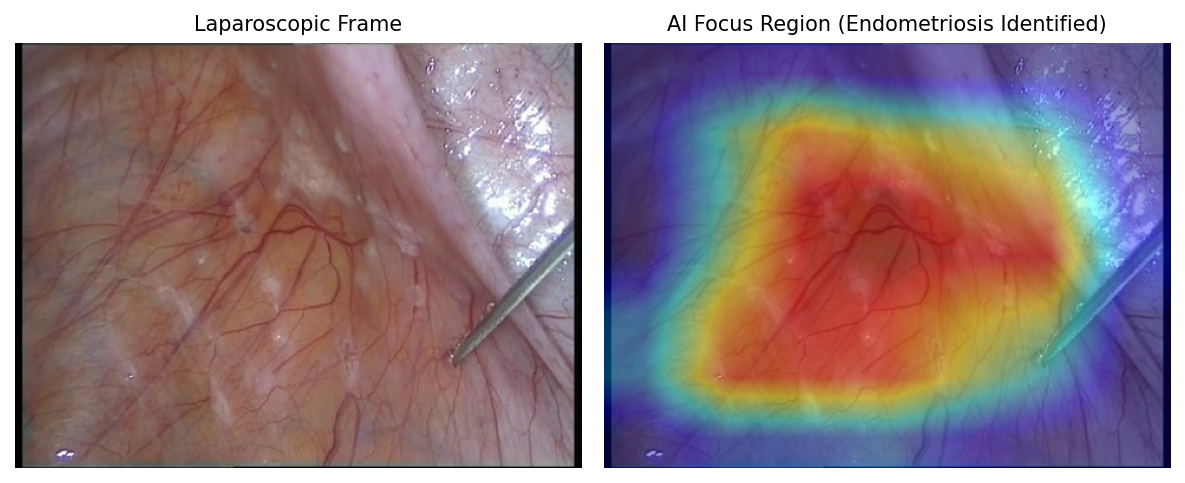


--- GEMINI PATIENT EXPLANATION ---



Here is a clear, supportive breakdown of your surgical findings and AI analysis:

---

### 1. Visual Findings Summary
* **Laparoscopic View (Left):** This image shows the tissue lining your pelvic area as seen through the surgical camera. 
* **AI Heatmap (Right):** The bright red and orange overlay shows the specific region where the AI concentrated its analysis. Within this highlighted area, the network identified subtle tissue variations, including small whitish spots (lesions) and distinct blood vessel patterns along the pelvic lining.

---

### 2. Clinical Interpretation
* **Result:** The AI model identified features strongly consistent with **endometriosis** (with a confidence score of 97.7%).
* **What This Means:** Endometriosis is a common condition where tissue similar to the lining of the uterus grows on other surfaces inside the pelvis. These growths can cause localized inflammation, which often explains symptoms such as pelvic pain, cramping, or discomfort. Identifying these subtle areas is a crucial step toward understanding the root cause of your symptoms.

---

### 3. Recommended Next Steps
* **Follow-Up Discussion:** Schedule a detailed post-operative consultation with your gynecologist or surgeon to review these findings together.
* **Treatment Planning:** Your physician will help tailor a personalized care plan based on your unique goals (such as pain management, hormonal treatment, or surgical removal of the tissue). 
* **Reassurance:** Having a clear, visual identification of these areas provides your healthcare team with actionable information to help you find effective relief and support going forward.


  ENDOSCAN AI — VISUAL REPORT FOR CASE: TEST_NEG_01


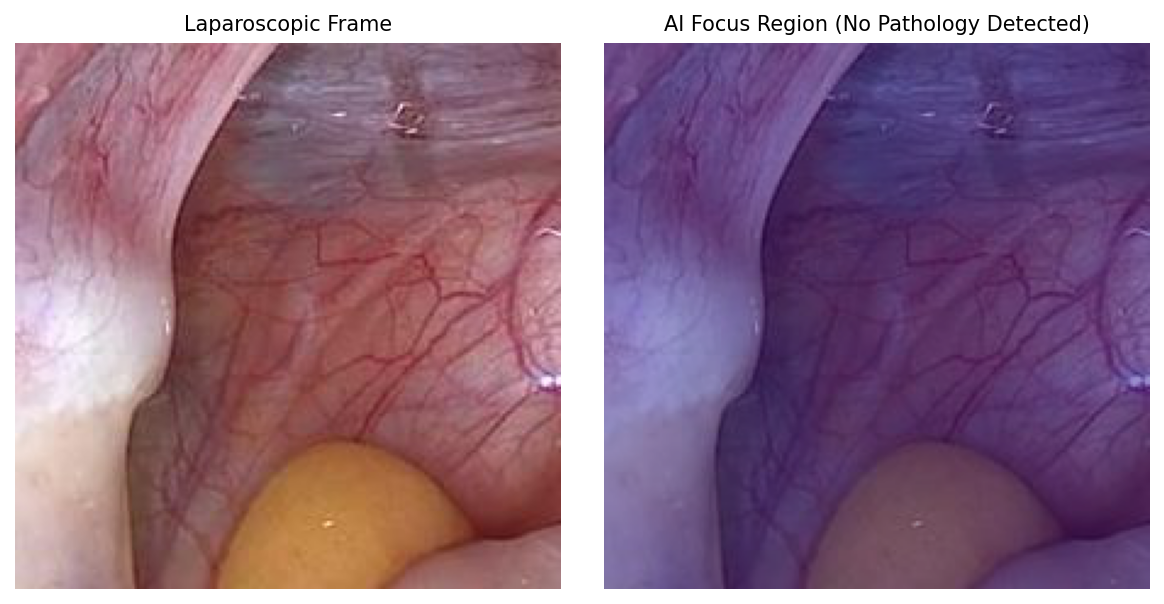


--- GEMINI PATIENT EXPLANATION ---



Here is a clear summary of the AI analysis for your records:

---

### 1. Visual Findings Summary
The AI evaluated the tissue in this frame of your procedure, placing its primary attention on the illuminated pelvic structures visible at the bottom and center of the view (shown by the lighter focused area in the right-hand image). Across the entire region examined, the model did not identify any dark spots, tissue scarring, or abnormal implants typically associated with endometriosis.

### 2. Clinical Interpretation
The model reported **No Endometriosis Visualized** with a high confidence level (**99.0%**). 

This is a reassuring result, indicating that the specific area captured in this image appears clear of visible endometriotic lesions. It suggests that the surface tissue in this field of view shows normal visual characteristics.

### 3. Recommended Next Steps
* **Consult Your Care Team:** While this individual frame shows no visible pathology, a complete evaluation involves reviewing the full video of your procedure alongside your overall symptoms and health history.
* **Discuss Next Steps:** Schedule a follow-up conversation with your surgeon or doctor to review the overall findings of your procedure and discuss the best plan for managing your symptoms moving forward.

In [67]:
# Cell 30c — Multimodal Visual Patient Report Generation
import os
import io
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from google import genai
from google.genai import types
from IPython.display import display, Markdown

# 1. Initialize Gemini Client safely
api_key = os.environ.get("GEMINI_API_KEY")
if not api_key:
    api_key = input("Enter your GEMINI_API_KEY: ").strip()
    os.environ["GEMINI_API_KEY"] = api_key

client = genai.Client(api_key=api_key)

# 2. Setup Output Directory
REPORTS_DIR = Path('./outputs/patient_reports')
REPORTS_DIR.mkdir(parents=True, exist_ok=True)


def create_composite_image(img_path, gradcam):
    """Generate side-by-side composite: Original Image | Grad-CAM Overlay."""
    raw_img = np.array(Image.open(img_path).convert('RGB'))
    result  = val_transform(image=raw_img)
    tensor  = result['image']

    prob, cam = gradcam.generate(tensor)

    # Resize CAM & blend with original image
    cam_resized = cv2.resize(cam, (raw_img.shape[1], raw_img.shape[0]))
    heatmap     = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap     = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay     = cv2.addWeighted(raw_img, 0.6, heatmap, 0.4, 0)

    # Plot figure into a PIL Image buffer
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(raw_img)
    axes[0].set_title("Laparoscopic Frame", fontsize=10)
    axes[0].axis('off')

    pred_text = "Endometriosis Identified" if prob > 0.5 else "No Pathology Detected"
    axes[1].imshow(overlay)
    axes[1].set_title(f"AI Focus Region ({pred_text})", fontsize=10)
    axes[1].axis('off')

    plt.tight_layout()

    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight', dpi=150)
    plt.close(fig)
    buf.seek(0)

    return Image.open(buf), prob


def generate_patient_report(img_path, case_id, gradcam, client_obj):
    composite_img, prob = create_composite_image(img_path, gradcam)

    diagnosis  = "Endometriosis Present" if prob > 0.5 else "No Endometriosis Visualized"
    confidence = prob if prob > 0.5 else (1.0 - prob)

    prompt = f"""
    You are an expert clinical AI assistant communicating laparoscopic findings to a patient.
    
    Model Output:
    - Finding: {diagnosis}
    - Model Confidence: {confidence * 100:.1f}%
    
    Attached is the diagnostic frame alongside a Grad-CAM heatmap overlay (where red/yellow highlights regions analyzed by the network).
    
    Please provide a concise, empathetic report with three sections:
    1. **Visual Findings Summary**: Explain what the model highlighted or evaluated in simple terms.
    2. **Clinical Interpretation**: Clear explanation of what the result means for the patient.
    3. **Recommended Next Steps**: Plain-language guidance on follow-up discussions with their physician.
    
    Keep the tone reassuring, objective, and easy to understand without dense medical jargon.
    """

    # Use active Gemini Flash model endpoint
    response = client_obj.models.generate_content(
        model='gemini-3.6-flash',
        contents=[composite_img, prompt]
    )

    # Display Visual Plot
    print("=" * 70)
    print(f"  ENDOSCAN AI — VISUAL REPORT FOR CASE: {case_id}")
    print("=" * 70)
    display(composite_img)
    
    # Render Formatted Markdown instead of raw text print
    print("\n--- GEMINI PATIENT EXPLANATION ---\n")
    display(Markdown(response.text))
    print("=" * 70 + "\n")

    # Save outputs to disk
    report_file = REPORTS_DIR / f"report_{case_id}.txt"
    img_file    = REPORTS_DIR / f"report_{case_id}.png"

    composite_img.save(img_file)
    with open(report_file, 'w') as f:
        f.write(f"Case ID: {case_id}\nDiagnosis: {diagnosis}\nConfidence: {confidence*100:.1f}%\n\n")
        f.write(response.text)


# ── Run Report Generation on Sample Test Cases ─────────────────────
sample_cases = [
    (test_dataset.samples[0][0], "TEST_POS_01"),
    (test_dataset.samples[-1][0], "TEST_NEG_01")
]

for img_path, case_id in sample_cases:
    generate_patient_report(img_path, case_id, gradcam, client)

In [65]:
# Cell 31 — Save Complete Model Checkpoint & Inference Metadata
import torch
from pathlib import Path

# Create outputs directory
output_dir = Path('./outputs')
output_dir.mkdir(parents=True, exist_ok=True)

save_path = output_dir / 'efficientnet_b0_endoscan_final.pt'

# Build state payload
checkpoint = {
    'model_state_dict': model.state_dict(),
    'architecture': 'efficientnet_b0',
    'class_mapping': {0: 'No endo', 1: 'Endo present'},
    'img_size': IMG_SIZE if 'IMG_SIZE' in globals() else 224,
    'auc_roc': auc if 'auc' in globals() else 0.9995,
    'history': history if 'history' in globals() else {},
    'model_version': 'v1.0'
}

# Save checkpoint
torch.save(checkpoint, save_path)

print("=" * 60)
print(f"Model successfully saved to: {save_path.resolve()}")
print(f"File Size: {save_path.stat().st_size / (1024 * 1024):.2f} MB")
print("=" * 60)

Model successfully saved to: /home/joy/Documents/DataScience/Module_6_Capstone/outputs/efficientnet_b0_endoscan_final.pt
File Size: 15.58 MB
